# Лабораторная работа 1

Machine Unlearning

## Сбор публикаций

импорт библиотек

In [1]:
import re
import time
import feedparser
import pandas as pd
import requests

формирование запроса:
- устанавливаю период в котором ищем нужные публикации
- ищу в названии статьи/аннотации machine unlearning

так же заранее завела константы которые будут использоваться дальше:
- api для запроса
- размер странцы
- минимальное значение количества собранных статей после для проверки
- время для паузы после запросов (тк в документации написано что между запросами должно быть не менее 3 секунд - https://info.arxiv.org/help/api/tou.html#rate-limits:~:text=When%20using%20the%20legacy%20APIs%20(including%20OAI%2DPMH%2C%20RSS%2C%20and%20the%20arXiv%20API)%2C%20make%20no%20more%20than%20one%20request%20every%20three%20seconds%2C%20and%20limit%20requests%20to%20a%20single%20connection%20at%20a%20time - взяла с запасом!)

In [2]:
API_URL = "https://export.arxiv.org/api/query"
DATE_FROM = "2020-01-01T00:00:00Z"
DATE_TO = "2026-09-20T21:47:00Z"
MIN_PUBLICATIONS = 300
PAGE_SIZE = 100
REQUEST_PAUSE = 3.3

start_time = pd.Timestamp(DATE_FROM)
end_time = pd.Timestamp(DATE_TO)
SEARCH_QUERY = (
    '(ti:"machine unlearning" OR abs:"machine unlearning") '
    f'AND submittedDate:[{start_time.strftime("%Y%m%d%H%M")} '
    f'TO {end_time.strftime("%Y%m%d%H%M")}]'
)

выгрузка статей

arXiv дает ответ в формате Atom/XML (в отличие от OpenAlex - там ответ в формате json), поэтому необходимо использовать feedparser.parse()

ниже описана функция, которая получает только 1 страницу - в ячейке после нее в цикле получаю нужно количество статей


In [3]:
def fetch_page(start):
    params = {
        "search_query": SEARCH_QUERY,
        "start": start,
        "max_results": PAGE_SIZE,
        "sortBy": "submittedDate",
        "sortOrder": "ascending",
    }
    time.sleep(REQUEST_PAUSE)
    response = requests.get(API_URL, params=params, timeout=60)
    response.raise_for_status()
    feed = feedparser.parse(response.content)
    total = int(feed.feed["opensearch_totalresults"])
    return feed.entries, total


In [4]:
records = []
start = 0
total = None
raw_df = df = None

while total is None or start < total:
    entries, page_total = fetch_page(start)
    if total is None:
        total = page_total
        if total < MIN_PUBLICATIONS:
            raise ValueError("найдено меньше 300 работ")

    for entry in entries:
        version_id = entry.get("id", "").rstrip("/").rsplit("/", 1)[-1]
        arxiv_id = re.sub(r"v\d+$", "", version_id)
        records.append({
            "arxiv_id": arxiv_id,
            "version_id": version_id,
            "title": entry.get("title", ""),
            "authors": [author.get("name", "") for author in entry.get("authors", [])],
            "abstract": entry.get("summary", ""),
            "published": entry.get("published", ""),
            "updated": entry.get("updated", ""),
            "url": f"https://arxiv.org/abs/{arxiv_id}",
            "categories": [tag.get("term", "") for tag in entry.get("tags", [])],
        })

    start += len(entries)
    print(f"получено {len(records)} / {total}")


получено 100 / 856
получено 200 / 856
получено 300 / 856
получено 400 / 856
получено 500 / 856
получено 600 / 856
получено 700 / 856
получено 800 / 856
получено 856 / 856


подготовка и проверка таблицы

нужно:
- исправить пробелы/переносы
- перевести даты в UTC
- удалить неполные записи
- удалить статьи вне периода
- не должно быть дублей одной и той же статьи

In [5]:
raw_df = pd.DataFrame(records)
df = raw_df.copy()

def compact_spaces(text):
    return " ".join(str(text or "").split())

for column in ("title", "abstract"):
    df[column] = df[column].map(compact_spaces)
df["authors"] = df["authors"].map(
    lambda names: [compact_spaces(name) for name in names if compact_spaces(name)]
)
for column in ("published", "updated"):
    df[column] = pd.to_datetime(df[column], utc=True, errors="coerce")

valid = (
    df["arxiv_id"].str.fullmatch(r"\d{4}\.\d{4,5}")
    & df["title"].ne("")
    & df["abstract"].ne("")
    & df["authors"].map(len).gt(0)
    & df["published"].between(start_time, end_time)
)
df = (
    df.loc[valid]
    .sort_values(["updated", "version_id"], na_position="first")
    .drop_duplicates("arxiv_id", keep="last")
    .sort_values(["published", "arxiv_id"])
    .reset_index(drop=True)
)
print(f"получено: {len(raw_df)}; исключено: {len(raw_df) - len(df)}; осталось: {len(df)}.")

получено: 856; исключено: 0; осталось: 856.


In [6]:
assert len(df) >= MIN_PUBLICATIONS, "меньше 300 публикаций"
assert df["arxiv_id"].is_unique, "есть повторные ID"
assert df["title"].str.strip().ne("").all(), "есть пустые названия"
assert df["abstract"].str.strip().ne("").all(), "есть пустые аннотации"
assert df["authors"].map(lambda names: bool(names) and all(names)).all(), "не заполнены авторы"
assert df["published"].between(start_time, end_time).all(), "есть даты вне периода"
print("все хорошо:)")

все хорошо:)


и пример что собралось

In [7]:
display(df[["title", "published", "url"]].sample(5, random_state=42))
print(
    f"уникальных публикаций: {len(df)}\n"
    f"даты публикаций: {df['published'].min().date()} — "f"{df['published'].max().date()}\n"
)

,title,published,url
711,From Anchors to Supervision: Memory-Graph Guid...,2026-04-15 12:07:14+00:00,https://arxiv.org/abs/2604.13777
603,Forget-It-All: Multi-Concept Machine Unlearnin...,2026-01-07 00:13:36+00:00,https://arxiv.org/abs/2601.06163
120,Layer Attack Unlearning: Fast and Accurate Mac...,2023-12-28 04:38:06+00:00,https://arxiv.org/abs/2312.16823
208,Recent Advances in Federated Learning Driven L...,2024-06-14 08:40:58+00:00,https://arxiv.org/abs/2406.09831
380,Benchmarking Federated Machine Unlearning meth...,2025-04-01 15:53:36+00:00,https://arxiv.org/abs/2504.00921


уникальных публикаций: 856
даты публикаций: 2020-02-07 — 2026-09-18



## Разведочный анализ

токенизацию повторила как в лекции: нижний регистр и последовательности английских букв [a-z]+ - ровно по этой причине model и models пока разные слова, model-based разбивается на два токена, стоп-слова сохраняю для длин и Ципфа - исключаю их только из второго топ-20


In [8]:
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from IPython.display import Markdown

def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())

eda_df = df.copy(deep=True)
eda_df["year"] = eda_df["published"].dt.year
eda_df["title_tokens"] = eda_df["title"].fillna("").map(tokenize)
eda_df["abstract_tokens"] = eda_df["abstract"].fillna("").map(tokenize)
eda_df["title_length"] = eda_df["title_tokens"].map(len)
eda_df["abstract_length"] = eda_df["abstract_tokens"].map(len)
eda_df["tokens"] = eda_df["title_tokens"] + eda_df["abstract_tokens"]

zero_tokens = eda_df["tokens"].map(len).eq(0)
print(f"документов без буквенных токенов: {zero_tokens.sum()}. строки не удаляю.")
if zero_tokens.any():
    display(eda_df.loc[zero_tokens, ["arxiv_id", "title", "url"]].head(5))


документов без буквенных токенов: 0. строки не удаляю.


### Паспорт корпуса

для сравнения текстов привожу их к нижнему регистру и одинаковым пробелам

число повторов — количество строк сверх первой в каждой группе одинаковых значений

In [9]:
normalized_titles = eda_df["title"].fillna("").str.lower().str.split().str.join(" ")
normalized_abstracts = eda_df["abstract"].fillna("").str.lower().str.split().str.join(" ")
missing_authors = eda_df["authors"].map(
    lambda names: not isinstance(names, list)
    or not any(isinstance(name, str) and name.strip() for name in names)
)
corpus_summary = pd.DataFrame({
    "показатель": [
        "Публикаций", "Первая дата", "Последняя дата",
        "Пустых названий", "Пустых аннотаций", "Не заполнены авторы",
        "Повторных ID", "Повторных названий", "Повторных аннотаций",
    ],
    "значение": [
        len(eda_df), str(eda_df["published"].min().date()), str(eda_df["published"].max().date()),
        int(normalized_titles.eq("").sum()), int(normalized_abstracts.eq("").sum()),
        int(missing_authors.sum()), int(eda_df["arxiv_id"].duplicated().sum()),
        int(normalized_titles.duplicated().sum()), int(normalized_abstracts.duplicated().sum()),
    ],
})
display(corpus_summary)

repeated_texts = normalized_titles.duplicated(keep=False) | normalized_abstracts.duplicated(keep=False)
if repeated_texts.any():
    print("примеры публикаций с повторяющимися названиями или аннотациями:")
    display(eda_df.loc[repeated_texts, ["arxiv_id", "title", "url"]].head(5))


,показатель,значение
0,Публикаций,856
1,Первая дата,2020-02-07
2,Последняя дата,2026-09-18
3,Пустых названий,0
4,Пустых аннотаций,0
5,Не заполнены авторы,0
6,Повторных ID,0
7,Повторных названий,2
8,Повторных аннотаций,1


примеры публикаций с повторяющимися названиями или аннотациями:


,arxiv_id,title,url
134,2404.16841,Machine Unlearning in Large Language Models,https://arxiv.org/abs/2404.16841
184,2405.15152,Machine Unlearning in Large Language Models,https://arxiv.org/abs/2405.15152
385,2504.06407,Understanding Machine Unlearning Through the L...,https://arxiv.org/abs/2504.06407
815,2607.23970,Understanding Machine Unlearning Through the L...,https://arxiv.org/abs/2607.23970


публикации по годам

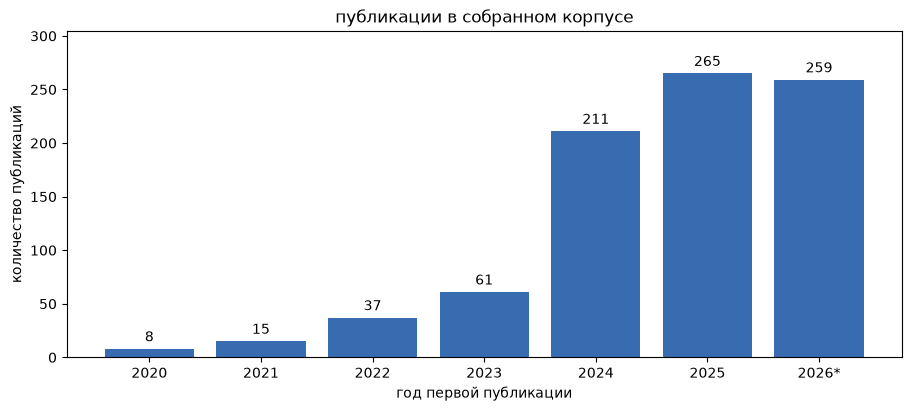

больше всего работ в выборке за 2025: 265.
граница выборки: 20.09.2026 21:47 UTC.


In [10]:
first_year = pd.Timestamp(DATE_FROM).year
cutoff = pd.Timestamp(DATE_TO)
year_counts = eda_df["year"].value_counts().reindex(
    range(first_year, cutoff.year + 1), fill_value=0
).sort_index()
last_year_end = pd.Timestamp(f"{cutoff.year + 1}-01-01", tz="UTC") - pd.Timedelta(minutes=1)
partial_last_year = cutoff < last_year_end

fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")
bars = ax.bar(year_counts.index, year_counts.values, color="#386CB0")
ax.bar_label(bars, padding=3)
ax.set_xticks(year_counts.index, [
    f"{year}*" if partial_last_year and year == cutoff.year else str(year)
    for year in year_counts.index
])
ax.set(title="публикации в собранном корпусе", xlabel="год первой публикации",
       ylabel="количество публикаций", ylim=(0, max(1, year_counts.max()) * 1.15))
plt.show()

peak_years = ", ".join(map(str, year_counts.index[year_counts.eq(year_counts.max())]))
print(f"больше всего работ в выборке за {peak_years}: {year_counts.max()}.")
print(f"граница выборки: {cutoff.strftime('%d.%m.%Y %H:%M UTC')}.")

длины названий и аннотаций

медиана показывает типичную длину, квартили описывают разброс

,"Название, токены","Аннотация, токены"
Минимум,2.0,82.0
Первый квартиль,7.0,163.8
Медиана,9.5,193.0
Среднее,9.5,193.4
Третий квартиль,12.0,222.0
Максимум,21.0,304.0


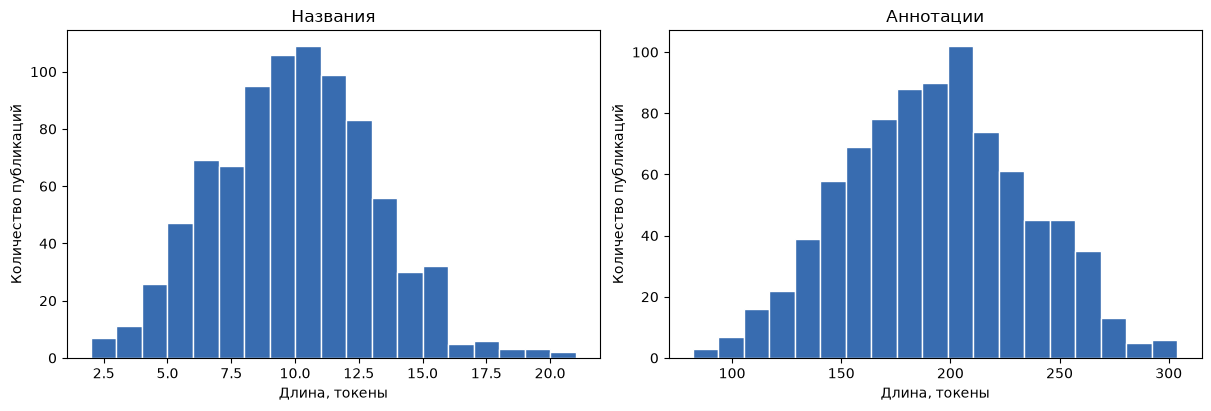

три самые короткие аннотации


,title,abstract_length,url
500,Analise de Desaprendizado de Maquina em Modelo...,82,https://arxiv.org/abs/2508.18509
504,Unleashing Uncertainty: Efficient Machine Unle...,85,https://arxiv.org/abs/2508.20773
12,A unified PAC-Bayesian framework for machine u...,93,https://arxiv.org/abs/2106.00265


три самые длинные аннотации


,title,abstract_length,url
111,Machine Unlearning in Learned Databases: An Ex...,304,https://arxiv.org/abs/2311.17276
23,Zero-Shot Machine Unlearning,299,https://arxiv.org/abs/2201.05629
20,Fast Yet Effective Machine Unlearning,298,https://arxiv.org/abs/2111.08947


In [11]:
length_stats = eda_df[["title_length", "abstract_length"]].describe().loc[
    ["min", "25%", "50%", "mean", "75%", "max"]
].rename(
    index={"min": "Минимум", "25%": "Первый квартиль", "50%": "Медиана",
           "mean": "Среднее", "75%": "Третий квартиль", "max": "Максимум"},
    columns={"title_length": "Название, токены", "abstract_length": "Аннотация, токены"},
)
display(length_stats.round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for ax, column, title in zip(axes, ["title_length", "abstract_length"], ["Названия", "Аннотации"]):
    ax.hist(eda_df[column], bins="auto", color="#386CB0", edgecolor="white")
    ax.set(title=title, xlabel="Длина, токены", ylabel="Количество публикаций")
plt.show()

for label, sample in [
    ("три самые короткие аннотации", eda_df.nsmallest(3, "abstract_length")),
    ("три самые длинные аннотации", eda_df.nlargest(3, "abstract_length")),
]:
    print(label)
    display(sample[["title", "abstract_length", "url"]])


частоты слов

корпусная частота — сколько раз слово встретилось во всех названиях и аннотациях

документная частота — в скольких статьях оно есть хотя бы один раз

N — число всех токенов, V — число различных токенов

Слова с частотой 1 называются hapax legomena - их долю считаю именно среди различных слов, а не среди всех вхождений

для второго топ-20 беру готовый ENGLISH_STOP_WORDS из scikit-learn без собственных дополнений


In [12]:
word_counts = Counter()
document_counts = Counter()
for tokens in eda_df["tokens"]:
    word_counts.update(tokens)
    document_counts.update(set(tokens))

word_stats = pd.DataFrame([
    {"word": word, "frequency": frequency, "document_frequency": document_counts[word]}
    for word, frequency in word_counts.items()
]).sort_values(["frequency", "word"], ascending=[False, True]).reset_index(drop=True)
word_stats["rank"] = range(1, len(word_stats) + 1)

n_tokens = sum(word_counts.values())
vocabulary_size = len(word_counts)
hapax_count = int(word_stats["frequency"].eq(1).sum())
display(pd.DataFrame({
    "показатель": ["Всего токенов N", "Различных слов V", "Слов с частотой 1", "Их доля среди V, %"],
    "значение": [n_tokens, vocabulary_size, hapax_count, round(100 * hapax_count / vocabulary_size, 1)],
}))
display(word_stats.head(10))


,показатель,значение
0,Всего токенов N,173662.0
1,Различных слов V,8289.0
2,Слов с частотой 1,2710.0
3,"Их доля среди V, %",32.7


,word,frequency,document_frequency,rank
0,the,7393,850,1
1,unlearning,4989,856,2
2,to,4563,852,3
3,and,4479,846,4
4,of,3992,828,5
5,a,3642,844,6
6,in,2660,808,7
7,we,2262,822,8
8,data,2154,670,9
9,for,2062,757,10


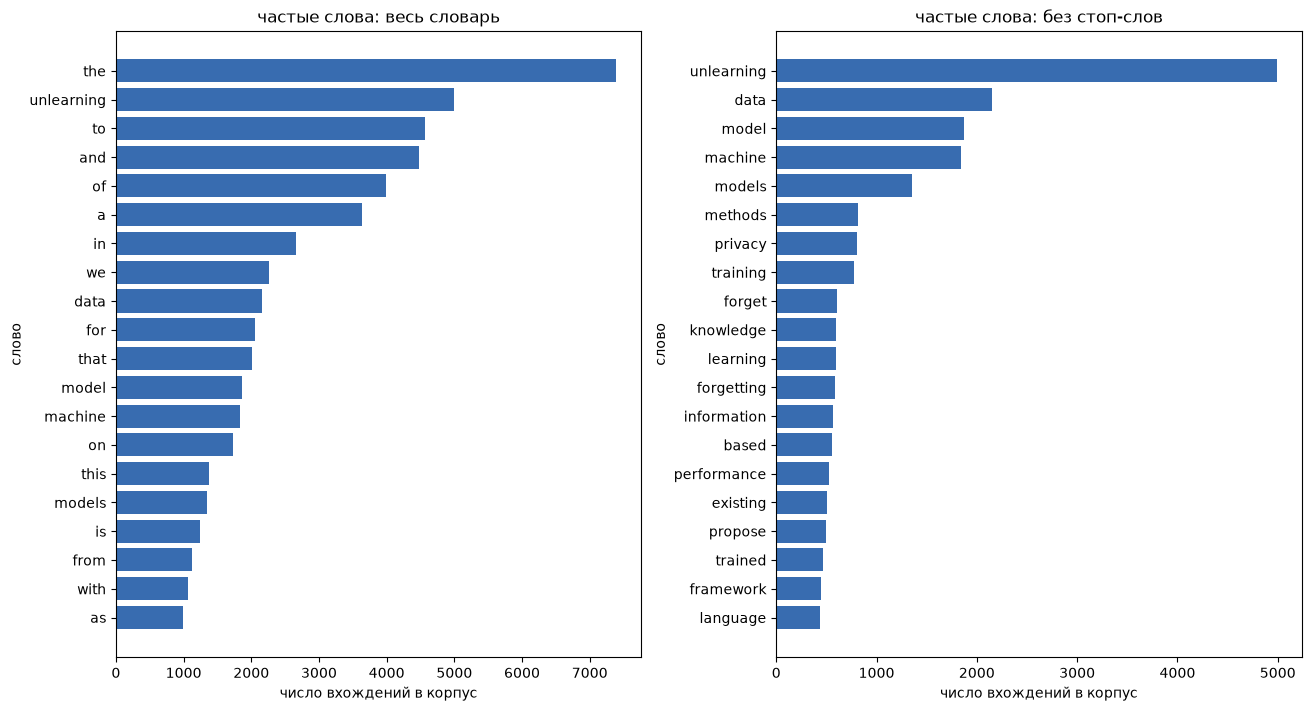

In [13]:
top_words = word_stats.head(20)
content_words = word_stats.loc[~word_stats["word"].isin(ENGLISH_STOP_WORDS)]
top_content = content_words.head(20)

fig, axes = plt.subplots(1, 2, figsize=(13, 7), layout="constrained")
for ax, table, title in zip(
    axes, [top_words, top_content], ["частые слова: весь словарь", "частые слова: без стоп-слов"]
):
    if table.empty:
        ax.text(0.5, 0.5, "после удаления стоп-слов\nне осталось токенов",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_yticks([])
    else:
        ax.barh(table["word"], table["frequency"], color="#386CB0")
        ax.invert_yaxis()
    ax.set(title=title, xlabel="число вхождений в корпус", ylabel="слово")
plt.show()

проверка закона Ципфа

ранг r — место слова в списке по убыванию частоты, начиная с 1

закон Ципфа описывает приблизительную зависимость:

$$f(r) \approx \frac{C}{r^s}, \qquad s \approx 1.$$

на log-log графике степенная зависимость выглядит примерно прямой: $\log f(r) \approx \log C - s\log r$

Строю распределение по всему базовому словарю: со стоп-словами, без лемматизации и удаления редких слов. Для сравнения добавляю f(1)/r — ориентир с s = 1, привязанный к самому частому слову, а не подобранную модель


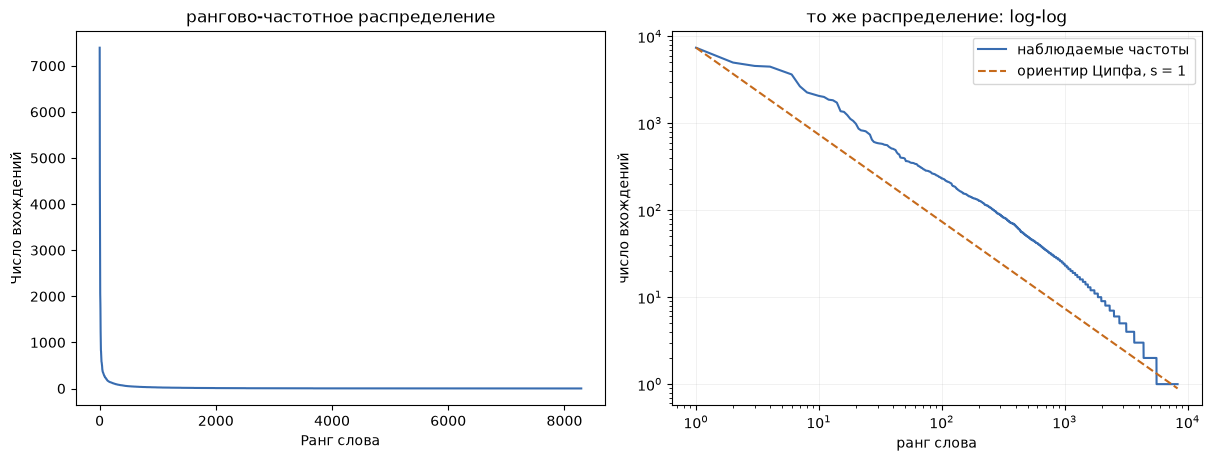

на графике 8289 слов, частота первого — 7393.
ступень частоты 1: ранги 5580–8289, всего 2710 слов


In [14]:
ranks = word_stats["rank"]
frequencies = word_stats["frequency"]
zipf_reference = frequencies.iloc[0] / ranks
point_marker = "o" if vocabulary_size == 1 else None

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
axes[0].plot(ranks, frequencies, color="#386CB0", linewidth=1.5, marker=point_marker)
axes[0].set(title="рангово-частотное распределение", xlabel="Ранг слова", ylabel="Число вхождений")
axes[1].loglog(ranks, frequencies, color="#386CB0", linewidth=1.5, marker=point_marker, label="наблюдаемые частоты")
axes[1].loglog(ranks, zipf_reference, "--", color="#C66A1B", label="ориентир Ципфа, s = 1")
axes[1].set(title="то же распределение: log-log", xlabel="ранг слова", ylabel="число вхождений")
axes[1].legend()
axes[1].grid(alpha=0.25, which="major")
plt.show()

print(f"на графике {vocabulary_size} слов, частота первого — {frequencies.iloc[0]}.")
if hapax_count:
    first_hapax_rank = int(word_stats.loc[word_stats["frequency"].eq(1), "rank"].iloc[0])
    print(f"ступень частоты 1: ранги {first_hapax_rank}–{vocabulary_size}, всего {hapax_count} слов")


### что видно на полученных графиках

- в выборке число публикаций увеличивается от 2020 до 2025 года - особенно заметен переход от 2023 к 2024 году, но столбец 2026 года относится только к части года - меньшая высота по сравнению с 2025 годом не доказывает снижение интереса к теме - пока еще могут быть загружены новые исследования, для точного сравнения стоит выбирать уже полностью прошедшие года
- названия сосредоточены около 10 токенов, аннотации — около 190–200, среднее и медиана длины аннотаций близки. Короткие и длинные тексты встречаются реже, но сама длина не означает ошибку данных
- в общем топе много служебных слов, например the, to, and, а без стоп-слов заметнее data, model, privacy, training, при этом model и models занимают разные позиции - формы пока не объединены. Частоты machine и unlearning зависят и от поисковой фразы, поэтому их нельзя трактовать как независимое открытие анализа
- на обычных осях видны резкое падение частот и длинный хвост. На log-log графике часть средних рангов близка к прямой, но весь график изгибается и на большей части диапазона проходит выше ориентира f(1)/r. То есть видна приблизительная рангово-частотная закономерность, а не точное выполнение закона с s = 1. Ступени в хвосте возникают из-за одинаковых целых частот, последняя ступень соответствует словам, встретившимся один раз


## Выделение ключевых слов

Теперь ищу характерные термины **каждой публикации**, а не просто частые слова корпуса.
Один документ — название и аннотация статьи, каждое поле учитываю один раз.
Результат: до 10 нормализованных тегов из 1–3 слов и их веса TF-IDF.
Исходные `df`, `eda_df` и `word_stats` не меняю; новые результаты — `keywords_df` и `keyword_details`.

Для лемматизации использую spaCy и `en_core_web_sm`. Отключаю только `ner`:
части речи нужны английскому лемматизатору, а синтаксический анализатор сохраняет границы предложений.
Это небольшая языковая модель для анализа текста, не генеративная модель.
[Как устроена лемматизация spaCy](https://spacy.io/usage/linguistic-features#lemmatization).
Команды установки ниже закомментированы: их достаточно выполнить один раз в текущем ядре;
после установки при необходимости перезапустить ядро.


In [16]:
import sys
import math
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer

# Установка в Python текущего ядра — раскомментировать только при необходимости:
# !"{sys.executable}" -m pip install spacy
# !"{sys.executable}" -m spacy download en_core_web_sm

if "df" not in globals() or df is None or df.empty:
    raise ValueError("Сначала выполните раздел сбора данных: df отсутствует или пуста.")

try:
    import spacy
except ImportError as exc:
    raise ImportError("Установите spaCy командой из начала этой ячейки.") from exc

try:
    kw_nlp = spacy.load("en_core_web_sm", disable=["ner"])
except OSError as exc:
    raise RuntimeError("Не найдена en_core_web_sm. Выполните команду загрузки модели выше.") from exc

KW_MAX_NGRAM = 3
KW_MIN_DF = 2
KW_MAX_DF = 0.9
KW_TOP_K = 10
KW_SUBLINEAR_TF = True
KW_SMOOTH_IDF = True
KW_NORM = "l2"

print(f"spaCy {spacy.__version__}; en_core_web_sm {kw_nlp.meta['version']}")


spaCy 3.8.16; en_core_web_sm 3.8.0


### Нормализация и кандидаты

В spaCy передаю исходный регистр, а полученные леммы привожу к нижнему:
например, `Neural networks` → `neural network`. Допускаю только английские
буквенные токены и леммы длиной не менее двух букв.

Дефисы `-`, `‐`, `‑` между английскими буквами заменяю одним пробелом.
Остальные знаки, цифры и недопустимые токены остаются границами.
Внутри каждого предложения перебираю непрерывные окна из 1–3 токенов,
не пересекая границы названия и аннотации. Исходное написание сохраняю по позиции в тексте.

Если исходная форма **или лемма** хотя бы одного слова входит в готовый
`ENGLISH_STOP_WORDS`, отклоняю всё окно. Стоп-слова не склеивают соседей:
из `learning for privacy` не получится `learning privacy`.
Список не универсален и собственных дополнений к нему здесь нет
([оговорки scikit-learn](https://scikit-learn.org/stable/modules/feature_extraction.html#using-stop-words)).
Повторы кандидатов нужны для TF; вложенные фразы сохраняю. Стемминг,
исправление опечаток, фильтр частей речи и объединение сокращений не применяю.
Обозначения моделей с цифрами могут учитываться неполно.


In [17]:
def kw_extract(text):
    # Замена символа на символ сохраняет позиции для исходных фрагментов.
    prepared = re.sub(r"(?<=[A-Za-z])[-‐‑](?=[A-Za-z])", " ", text)
    parsed = kw_nlp(prepared)
    candidates, surfaces = [], {}
    for sentence in parsed.sents:
        tokens = list(sentence)
        for start in range(len(tokens)):
            lemmas = []
            for token in tokens[start:start + KW_MAX_NGRAM]:
                surface, lemma = token.text.lower(), token.lemma_.lower()
                if (not re.fullmatch(r"[A-Za-z]{2,}", token.text)
                        or not re.fullmatch(r"[a-z]{2,}", lemma)
                        or surface in ENGLISH_STOP_WORDS
                        or lemma in ENGLISH_STOP_WORDS):
                    break  # Через этот токен ни одно продолжение окна не проходит.
                lemmas.append(lemma)
                term = " ".join(lemmas)
                candidates.append(term)
                fragment = text[tokens[start].idx:token.idx + len(token.text)]
                surfaces.setdefault(term, fragment)
    return candidates, surfaces


def kw_article_candidates(title, abstract):
    title_terms, surfaces = kw_extract(title)
    abstract_terms, abstract_surfaces = kw_extract(abstract)
    for term, surface in abstract_surfaces.items():
        surfaces.setdefault(term, surface)  # Первое в названии, иначе в аннотации.
    return title_terms + abstract_terms, surfaces


kw_documents, kw_surface_forms = [], []
for kw_title, kw_abstract in df[["title", "abstract"]].fillna("").itertuples(index=False, name=None):
    kw_candidates, kw_surfaces = kw_article_candidates(kw_title, kw_abstract)
    kw_documents.append(kw_candidates)
    kw_surface_forms.append(kw_surfaces)

print(f"Обработано публикаций: {len(kw_documents)}")


Обработано публикаций: 856


### Общий словарь и пороги

Корпусная частота считает все вхождения кандидата, документная — статьи,
в которых он встретился хотя бы раз. Название и аннотация — один документ:
вхождение в обоих полях увеличивает TF, но не удваивает DF.

Оставляю целые кандидаты с $DF \geq 2$ и $DF / D \leq 0.9$,
где $D$ — число публикаций. Удаление слишком распространённого отдельного слова
не удаляет автоматически более специфичную фразу с ним. Пороги не подбираю по результату.


In [18]:
def kw_count_candidates(documents):
    frequencies, document_frequencies = Counter(), Counter()
    for terms in documents:
        frequencies.update(terms)
        document_frequencies.update(set(terms))
    return pd.DataFrame([
        {"keyword": term, "frequency": count,
         "document_frequency": document_frequencies[term]}
        for term, count in frequencies.items()
    ], columns=["keyword", "frequency", "document_frequency"]).sort_values(
        ["frequency", "keyword"], ascending=[False, True]
    ).reset_index(drop=True)


kw_candidate_stats = kw_count_candidates(kw_documents)
kw_allowed = (kw_candidate_stats["document_frequency"].ge(KW_MIN_DF)
              & kw_candidate_stats["document_frequency"].le(KW_MAX_DF * len(kw_documents)))
print(f"Различных кандидатов до порогов: {len(kw_candidate_stats)}; после: {kw_allowed.sum()}")
for kw_label, kw_mask in [
    ("Примеры слишком редких", kw_candidate_stats["document_frequency"].lt(KW_MIN_DF)),
    ("Примеры слишком распространённых",
     kw_candidate_stats["document_frequency"].gt(KW_MAX_DF * len(kw_documents))),
]:
    print(kw_label)
    display(kw_candidate_stats.loc[kw_mask].head(5))


Различных кандидатов до порогов: 51628; после: 9742
Примеры слишком редких


,keyword,frequency,document_frequency
1775,db,11,1
1948,lambda,10,1
2065,computational unlearning,9,1
2144,mcmc,9,1
2159,okb,9,1


Примеры слишком распространённых


,keyword,frequency,document_frequency
0,unlearning,4313,849
1,model,3070,801
2,machine,1830,855
4,machine unlearning,1428,817


### Веса TF-IDF

Обучаю один `TfidfVectorizer` на всём корпусе. Мой анализатор получает уже готовый
список кандидатов и возвращает его без разбиения: `large language model` — один признак.
Поэтому `ngram_range`, `stop_words` и стандартную токенизацию повторно не применяю.
[Документация анализатора](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html).

При $c(t,d)>0$ использую:

$$TF(t,d)=1+\ln c(t,d), \qquad IDF(t)=\ln\frac{1+D}{1+DF(t)}+1.$$

Здесь $c(t,d)$ — число вхождений термина в статье, $D$ — число статей.
Отсутствующим терминам соответствует нулевой вес. Произведения TF и IDF
делю на L2-норму строки; это не меняет порядок весов внутри статьи.
Численная нормализация вектора не заменяет лемматизацию текста.
[Формулы scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfTransformer.html).


In [19]:
def kw_identity_analyzer(terms):
    return terms


def kw_fit_tfidf(documents):
    stats = kw_count_candidates(documents)
    if stats.empty:
        raise ValueError("Словарь кандидатов пуст: проверьте тексты и правила нормализации.")
    allowed = (stats["document_frequency"].ge(KW_MIN_DF)
               & stats["document_frequency"].le(KW_MAX_DF * len(documents)))
    if not allowed.any():
        raise ValueError("После min_df=2 и max_df=0.9 словарь пуст. Пороги автоматически не меняются.")
    vectorizer = TfidfVectorizer(
        analyzer=kw_identity_analyzer,
        min_df=KW_MIN_DF, max_df=KW_MAX_DF,
        sublinear_tf=KW_SUBLINEAR_TF, smooth_idf=KW_SMOOTH_IDF, norm=KW_NORM,
    )
    return vectorizer, vectorizer.fit_transform(documents)


kw_vectorizer, kw_matrix = kw_fit_tfidf(kw_documents)
kw_terms = kw_vectorizer.get_feature_names_out()
assert set(kw_terms) == set(kw_candidate_stats.loc[kw_allowed, "keyword"])
print(f"Разреженная матрица: {kw_matrix.shape[0]} публикаций × {kw_matrix.shape[1]} терминов")


Разреженная матрица: 856 публикаций × 9742 терминов


### До 10 тегов на статью

Беру только положительные веса, сортирую по убыванию TF-IDF, при равенстве —
по алфавиту. В `keywords_df` сохраняю списки строк, а в `keyword_details` —
исходный фрагмент, вес, длину термина и его DF **до отбора топ-10**.
Если у статьи не осталось кандидатов, сохраняю пустой список, не удаляю статью
и не дополняю её выдуманными тегами.


In [20]:
def kw_rank_row(row, terms, limit=KW_TOP_K):
    weighted = [(str(terms[index]), float(score))
                for index, score in zip(row.indices, row.data) if score > 0]
    return sorted(weighted, key=lambda pair: (-pair[1], pair[0]))[:limit]


kw_df_lookup = kw_candidate_stats.set_index("keyword")["document_frequency"].to_dict()
kw_lists, kw_detail_rows = [], []
for kw_position, kw_id in enumerate(df["arxiv_id"]):
    kw_ranked = kw_rank_row(kw_matrix.getrow(kw_position), kw_terms)
    kw_lists.append([term for term, score in kw_ranked])
    for kw_term, kw_score in kw_ranked:
        kw_detail_rows.append({
            "arxiv_id": kw_id, "keyword": kw_term,
            "surface_form": kw_surface_forms[kw_position][kw_term],
            "score": kw_score, "ngram_size": len(kw_term.split()),
            "document_frequency": kw_df_lookup[kw_term],
        })

keywords_df = df.copy(deep=True)
keywords_df["keywords"] = kw_lists
keyword_details = pd.DataFrame(kw_detail_rows, columns=[
    "arxiv_id", "keyword", "surface_form", "score", "ngram_size", "document_frequency",
])
kw_empty = keywords_df["keywords"].map(len).eq(0)
print(f"Публикаций без тегов: {kw_empty.sum()}")
if kw_empty.any():
    display(keywords_df.loc[kw_empty, ["arxiv_id", "title", "url"]].head(5))
display(keywords_df[["arxiv_id", "title", "keywords"]].head(5))


Публикаций без тегов: 0

,arxiv_id,title,keywords
0,2002.02730,Machine Unlearning: Linear Filtration for Logi...,"[linear, adversarial setting, classifiers, spe..."
1,2003.04247,Towards Probabilistic Verification of Machine ...,"[verification mechanism, verification, high co..."
2,2003.10933,Learn to Forget: Machine Unlearning via Neuron...,"[rate, eliminate memorization, network memoriz..."
3,2005.02205,When Machine Unlearning Jeopardizes Privacy,"[ml model, ml, data owner, owner, classical, t..."
4,2007.02923,Descent-to-Delete: Gradient-Based Methods for ...,"[deletion algorithm, observable, statistically..."


### Содержательная проверка

Для просмотра выбираю 10 случайных статей (`random_state=42`), 5 с самыми
короткими и 5 с самыми длинными аннотациями **по числу символов**.
Повторяющиеся ID в этом наборе исключаю. В `kw_review_df` остаётся весь набор,
ниже — пять подробных примеров: название, аннотация, теги и веса.
Сопоставляю смысл статьи с терминами, проверяю леммы, границы фраз,
содержательные биграммы/триграммы, общие слова и вложенные варианты.


In [21]:
kw_review_pool = keywords_df[["arxiv_id", "title", "abstract", "url", "keywords"]].copy()
kw_review_pool["abstract_characters"] = kw_review_pool["abstract"].fillna("").str.len()
kw_review_df = pd.concat([
    kw_review_pool.sample(n=min(10, len(kw_review_pool)), random_state=42),
    kw_review_pool.nsmallest(5, "abstract_characters"),
    kw_review_pool.nlargest(5, "abstract_characters"),
]).drop_duplicates("arxiv_id").reset_index(drop=True)

print(f"В наборе для проверки {len(kw_review_df)} различных публикаций; ниже первые пять.")
for kw_example in kw_review_df.head(5).itertuples(index=False):
    print(f"\n{kw_example.title}\n{kw_example.url}")
    print(f"Аннотация: {kw_example.abstract}")
    display(keyword_details.loc[
        keyword_details["arxiv_id"].eq(kw_example.arxiv_id),
        ["keyword", "surface_form", "score", "ngram_size", "document_frequency"],
    ].reset_index(drop=True).round({"score": 4}))


В наборе для проверки 20 различных публикаций; ниже первые пять.

From Anchors to Supervision: Memory-Graph Guided Corpus-Free Unlearning for Large Language Models
https://arxiv.org/abs/2604.13777
Аннотация: Large language models (LLMs) may memorize sensitive or copyrighted content, raising significant privacy and legal concerns. While machine unlearning has emerged as a potential remedy, prevailing paradigms rely on user-provided forget sets, making unlearning requests difficult to audit and exposing systems to secondary leakage and malicious abuse. We propose MAGE, a Memory-grAph Guided Erasure framework for user-minimized, corpus-free unlearning. Given only a lightweight user anchor that identifies a target entity, MAGE probes the target LLM to recover target-related memorization, organizes it into a weighted local memory graph, and synthesizes scoped supervision for unlearning. MAGE is model-agnostic, can be plugged into standard unlearning methods, and requires no access to the or

,keyword,surface_form,score,ngram_size,document_frequency
0,mage,MAGE,0.2741,1,2
1,supervision,Supervision,0.2170,1,11
2,corpus free,Corpus-Free,0.1945,2,2
3,corpus free unlearning,Corpus-Free Unlearning,0.1945,3,2
4,corpus,Corpus,0.1804,1,15
5,graph,Graph,0.1542,1,32
6,free unlearning,Free Unlearning,0.1456,2,15
7,anchor,anchor,0.1438,1,16
8,memory,Memory,0.1438,1,43
9,guided,Guided,0.1282,1,28



Forget-It-All: Multi-Concept Machine Unlearning via Concept-Aware Neuron Masking
https://arxiv.org/abs/2601.06163
Аннотация: The widespread adoption of text-to-image (T2I) diffusion models has raised concerns about their potential to generate copyrighted, inappropriate, or sensitive imagery. As a practical solution, machine unlearning aims to erase unwanted concepts without retraining from scratch. While most existing methods are effective for single-concept unlearning, they often struggle when removing multiple concepts, causing significant challenges in unlearning effectiveness, generation quality, and sensitivity to hyperparameters and datasets. We take a unique perspective on multi-concept unlearning by leveraging model sparsity and propose the Forget It All (FIA) framework. FIA first introduces Contrastive Concept Saliency to quantify each weight connection's contribution to a target concept. It then identifies Concept Sensitive Neurons by combining temporal and spatial informati

,keyword,surface_form,score,ngram_size,document_frequency
0,multi concept,Multi-Concept,0.2419,2,4
1,concept unlearning,concept unlearning,0.2011,2,6
2,neuron,Neuron,0.1937,1,16
3,concept,Concept,0.1861,1,104
4,multi concept unlearning,multi-concept unlearning,0.1859,3,2
5,target concept,target concept,0.1449,2,12
6,hyperparameter,hyperparameters,0.1374,1,16
7,multi,Multi,0.1374,1,70
8,mask,masks,0.1256,1,25
9,generation,generation,0.1126,1,89



Layer Attack Unlearning: Fast and Accurate Machine Unlearning via Layer Level Attack and Knowledge Distillation
https://arxiv.org/abs/2312.16823
Аннотация: Recently, serious concerns have been raised about the privacy issues related to training datasets in machine learning algorithms when including personal data. Various regulations in different countries, including the GDPR grant individuals to have personal data erased, known as 'the right to be forgotten' or 'the right to erasure'. However, there has been less research on effectively and practically deleting the requested personal data from the training set while not jeopardizing the overall machine learning performance. In this work, we propose a fast and novel machine unlearning paradigm at the layer level called layer attack unlearning, which is highly accurate and fast compared to existing machine unlearning algorithms. We introduce the Partial-PGD algorithm to locate the samples to forget efficiently. In addition, we only use 

,keyword,surface_form,score,ngram_size,document_frequency
0,layer level,Layer Level,0.2060,2,3
1,layer,Layer,0.1800,1,62
2,personal datum,personal data,0.1773,2,27
3,knowledge distillation,Knowledge Distillation,0.1733,2,10
4,fast,Fast,0.1601,1,42
5,forward,Forward,0.1556,1,18
6,personal,personal,0.1541,1,49
7,accurate,Accurate,0.1419,1,28
8,distillation,Distillation,0.1349,1,35
9,end,end,0.1307,1,40



Recent Advances in Federated Learning Driven Large Language Models: A Survey on Architecture, Performance, and Security
https://arxiv.org/abs/2406.09831
Аннотация: Federated Learning (FL) offers a promising paradigm for training Large Language Models (LLMs) in a decentralized manner while preserving data privacy and minimizing communication overhead. This survey examines recent advancements in FL-driven LLMs, with a particular emphasis on architectural designs, performance optimization, and security concerns, including the emerging area of machine unlearning. In this context, machine unlearning refers to the systematic removal of specific data contributions from trained models to comply with privacy regulations such as the Right to be Forgotten. We review a range of strategies enabling unlearning in federated LLMs, including perturbation-based methods, model decomposition, and incremental retraining, while evaluating their trade-offs in terms of efficiency, privacy guarantees, and mod

,keyword,surface_form,score,ngram_size,document_frequency
0,fl,FL,0.1870,1,22
1,survey,Survey,0.1724,1,32
2,federate,federated,0.1495,1,23
3,federated learning,Federated Learning,0.1469,2,25
4,federated,Federated,0.1336,1,38
5,architectural,architectural,0.1284,1,2
6,communication overhead,communication overhead,0.1284,2,2
7,critical research direction,critical research directions,0.1284,3,2
8,decentralized manner,decentralized manner,0.1284,2,2
9,emerge area,emerging area,0.1284,2,2



Benchmarking Federated Machine Unlearning methods for Tabular Data
https://arxiv.org/abs/2504.00921
Аннотация: Machine unlearning, which enables a model to forget specific data upon request, is increasingly relevant in the era of privacy-centric machine learning, particularly within federated learning (FL) environments. This paper presents a pioneering study on benchmarking machine unlearning methods within a federated setting for tabular data, addressing the unique challenges posed by cross-silo FL where data privacy and communication efficiency are paramount. We explore unlearning at the feature and instance levels, employing both machine learning, random forest and logistic regression models. Our methodology benchmarks various unlearning algorithms, including fine-tuning and gradient-based approaches, across multiple datasets, with metrics focused on fidelity, certifiability, and computational efficiency. Experiments demonstrate that while fidelity remains high across methods, tree

,keyword,surface_form,score,ngram_size,document_frequency
0,certifiability,certifiability,0.1834,1,4
1,tabular,Tabular,0.1734,1,6
2,fl,FL,0.1709,1,22
3,benchmarke,Benchmarking,0.1573,1,11
4,computational efficiency,computational efficiency,0.1527,2,13
5,fidelity,fidelity,0.1436,1,18
6,environment,environments,0.1379,1,22
7,gradient base,gradient-based,0.1280,2,31
8,federated,Federated,0.1221,1,38
9,machine unlearning method,Machine Unlearning methods,0.1178,3,44


### Сводка результатов

Число назначений тега — сколько статей получило его **в итоговом топ-10**.
Это не DF кандидата: он мог встретиться в нескольких статьях, но попасть в топ-10 лишь одной.
В распределении по длине отдельно показываю назначения и различные выбранные теги.


In [22]:
kw_counts = keywords_df["keywords"].map(len)
kw_selected_counts = Counter(term for tags in keywords_df["keywords"] for term in tags)
kw_tag_counts = pd.DataFrame(
    kw_selected_counts.items(), columns=["keyword", "publications"]
).sort_values(["publications", "keyword"], ascending=[False, True]).reset_index(drop=True)

display(pd.DataFrame({
    "показатель": ["Публикаций с тегами", "Публикаций без тегов",
                  "Минимум тегов", "Медиана тегов", "Максимум тегов",
                  "Различных выбранных тегов", "Тегов, назначенных хотя бы двум статьям"],
    "значение": [int(kw_counts.gt(0).sum()), int(kw_counts.eq(0).sum()),
                 int(kw_counts.min()), float(kw_counts.median()), int(kw_counts.max()),
                 len(kw_tag_counts), int(kw_tag_counts["publications"].ge(2).sum())],
}))
kw_length_summary = pd.DataFrame({
    "слов в теге": [1, 2, 3],
    "назначений": keyword_details.groupby("ngram_size").size().reindex([1, 2, 3], fill_value=0).values,
    "различных тегов": keyword_details.groupby("ngram_size")["keyword"].nunique().reindex(
        [1, 2, 3], fill_value=0
    ).values,
})
display(kw_length_summary)
display(kw_tag_counts.head(20))


,показатель,значение
0,Публикаций с тегами,856.0
1,Публикаций без тегов,0.0
2,Минимум тегов,10.0
3,Медиана тегов,10.0
4,Максимум тегов,10.0
5,Различных выбранных тегов,4491.0
6,"Тегов, назначенных хотя бы двум статьям",1775.0


,слов в теге,назначений,различных тегов
0,1,4844,1924
1,2,3084,2083
2,3,632,484


,keyword,publications
0,mu,28
1,federated,24
2,graph,23
3,survey,21
4,diffusion,20
5,concept,19
6,multimodal,19
7,client,18
8,fl,18
9,backdoor,17


### Выводы по выделению ключевых слов

- В этом запуске обработаны 856 публикаций. Из 51 628 различных кандидатов пороги прошли 9 742. Каждая статья получила 10 тегов; пустых списков нет. Выбраны 4 491 различный тег: 1 924 униграммы, 2 083 биграммы и 484 триграммы. Число назначений по длинам — 4 844, 3 084 и 632 соответственно. Наличие тегов у всех статей означает охват, но не гарантирует содержательное качество каждого тега.
- По верхнему порогу исключены `machine` (DF = 855), `unlearning` (849), `machine unlearning` (817) и `model` (801): они встречаются более чем в 90% статей. Частота первых трёх связана и с поисковой фразой корпуса. Более специфичные фразы, например `machine unlearning method`, при этом сохраняются. Редкие кандидаты с DF = 1 исключены независимо от их возможной научной важности.
- Просмотрены все 20 статей проверочного набора: 10 случайных, 5 с короткими и 5 с длинными аннотациями, без повторов ID. Есть содержательно подходящие теги: `knowledge distillation` и `layer level` для работы о Layer Attack Unlearning; `multi concept unlearning` и `neuron` для Forget-It-All; `option`, `calibration` и `gauss newton` для работы об удалении данных при калибровке финансовой модели. Искусственного склеивания через стоп-слова, пунктуацию и поля в просмотренных примерах не обнаружено; эти границы также проверены учебными тестами.
- Ограничения лемматизации заметны: `Benchmarking` превратилось в неудачное `benchmarke`; `federated` в разных контекстах осталось `federated` или стало `federate`. `personal data` стало `personal datum`: морфологическая нормализация не всегда даёт привычное написание научного термина. В первой версии эти случаи не исправляю вручную.
- TF-IDF не проверяет смысл фраз. Встречаются общие слова и малоинформативные фрагменты: `fast`, `end`, `pose potential`, `benchmark primarily`. Одновременно выбираются вложенные варианты, например `corpus`, `corpus free`, `corpus free unlearning`. Ограничение тремя словами дробит длинные термины: из `zero-shot machine unlearning` получаются в том числе `shot machine` и `shot machine unlearning`. Это реальные соседние слова, но не всегда самостоятельные понятия.
- Частые итоговые теги включают `mu` (28 статей), `federated` (24), `graph` (23), `survey` (21) и `diffusion` (20). Сокращения (`fl`, `mllm` и другие) не объединены с полными формами. Из 4 491 выбранного тега только 1 775 назначены хотя бы двум статьям; оставшиеся 2 716 выбраны лишь для одной, хотя все кандидаты встречались минимум в двух документах. Поэтому min_df = 2 сам по себе не гарантирует связи между публикациями после отбора топ-10.
- Для следующего этапа готовы `keywords_df` и `keyword_details`. Общие теги могут связывать разные подтемы, а сокращения, варианты лемм и вложенные фразы — дробить представление одного понятия. Эти ограничения нужно учитывать при интерпретации будущих графов. Без эталонной разметки численную точность извлечения не оцениваю. Выводы относятся к текущей выборке и версиям модели, указанным в начале раздела.


## Граф ключевых слов

Строю общую сеть по готовым спискам `keywords_df["keywords"]`:
вершина — целый нормализованный термин, ребро — совместное назначение двух
разных тегов одной публикации. Вес ребра — число таких публикаций:

$$w(u,v)=\#\{d: u\in K_d,\ v\in K_d\},\quad u\ne v.$$

Граф неориентированный, без петель и параллельных рёбер. Одна статья даёт
паре ровно один вклад, независимо от повторов слов в тексте. TF-IDF уже
использован для отбора тегов и повторно в вес ребра не включается.
Все связи с весом 1 сохраняю. Статьи пока не являются вершинами.

Исходные таблицы не меняю. `publication_count` у вершины — число статей,
получивших тег, а не DF кандидата до отбора топ-10. У ребра сохраняю
`publication_ids`, чтобы можно было проверить его происхождение.
[Graph в NetworkX](https://networkx.org/documentation/stable/reference/classes/graph.html).

In [23]:
import sys
from collections import Counter
from itertools import combinations
from textwrap import fill

# Установка в Python текущего ядра — только при необходимости:
# !"{sys.executable}" -m pip install networkx
try:
    import networkx as nx
except ImportError as exc:
    raise ImportError("Установите NetworkX командой выше и повторите запуск раздела.") from exc


def build_keyword_graph(publications):
    if not isinstance(publications, pd.DataFrame) or publications.empty:
        raise ValueError("Сначала выполните выделение ключевых слов: keywords_df отсутствует или пуста.")
    required = {"arxiv_id", "keywords", "title", "url"}
    missing = required - set(publications.columns)
    if missing:
        raise ValueError(f"В keywords_df отсутствуют столбцы: {', '.join(sorted(missing))}.")
    if not publications["arxiv_id"].map(lambda value: isinstance(value, str) and bool(value.strip())).all():
        raise ValueError("arxiv_id должны быть непустыми строками; исходные ID не исправляются автоматически.")
    if publications["arxiv_id"].duplicated().any():
        raise ValueError("Найдены повторяющиеся arxiv_id: одна публикация не должна считаться несколько раз.")

    counts, pair_publications = Counter(), {}
    for article_id, terms in publications[["arxiv_id", "keywords"]].itertuples(index=False, name=None):
        if (not isinstance(terms, list)
                or any(not isinstance(term, str) or not term.strip() for term in terms)):
            raise ValueError(f"Некорректные keywords у {article_id}: нужен список непустых строк; [] допустим.")
        unique_terms = sorted(set(terms))  # Не меняю исходный список и не нормализую его заново.
        counts.update(unique_terms)
        for pair in combinations(unique_terms, 2):
            pair_publications.setdefault(pair, set()).add(article_id)

    graph = nx.Graph()
    for term in sorted(counts):
        graph.add_node(term, publication_count=counts[term])
    for (source, target), ids in sorted(pair_publications.items()):
        publication_ids = tuple(sorted(ids))
        graph.add_edge(source, target, weight=len(publication_ids), publication_ids=publication_ids)
    return graph


if "keywords_df" not in globals():
    raise ValueError("Сначала выполните раздел выделения ключевых слов, чтобы получить keywords_df.")
keyword_graph = build_keyword_graph(keywords_df)
keyword_edges = pd.DataFrame([
    {"source": min(source, target), "target": max(source, target),
     "weight": attributes["weight"], "publication_ids": attributes["publication_ids"]}
    for source, target, attributes in keyword_graph.edges(data=True)
], columns=["source", "target", "weight", "publication_ids"]).sort_values(
    ["weight", "source", "target"], ascending=[False, True, True]
).reset_index(drop=True)
print(f"NetworkX {nx.__version__}; полный граф построен без фильтрации рёбер.")

NetworkX 3.7; полный граф построен без фильтрации рёбер.


### Паспорт графа

Компонента связности — часть графа, внутри которой между любыми двумя
вершинами есть путь. Изолят — вершина без соседей.
Тег, назначенный единственной статье, не обязательно изолирован:
он связан с другими тегами той же статьи.

Сумма весов — не число разных рёбер. Статья с $k$ различными тегами
даёт $k(k-1)/2$ пар; повторяющиеся между статьями пары увеличивают вес.

In [24]:
kg_component_sizes = sorted((len(component) for component in nx.connected_components(keyword_graph)), reverse=True)
kg_total_weight = int(keyword_edges["weight"].sum())
kg_summary = pd.DataFrame({
    "показатель": ["Обработано публикаций", "Публикаций без тегов", "Вершин", "Рёбер",
                  "Сумма весов рёбер", "Компонент связности", "Вершин в крупнейшей компоненте", "Изолятов"],
    "значение": [len(keywords_df), int(keywords_df["keywords"].map(len).eq(0).sum()),
                 keyword_graph.number_of_nodes(), keyword_graph.number_of_edges(), kg_total_weight,
                 len(kg_component_sizes), max(kg_component_sizes, default=0),
                 nx.number_of_isolates(keyword_graph)],
})
display(kg_summary)
kg_weight_distribution = keyword_edges["weight"].value_counts().sort_index().rename_axis("weight").reset_index(name="edges")
print("Распределение: вес ребра — количество рёбер")
display(kg_weight_distribution)
print("До десяти самых сильных связей")
display(keyword_edges[["source", "target", "weight"]].head(10))
if keyword_graph.number_of_nodes() == 0:
    print("Выбранных терминов нет: граф пуст.")
elif keyword_graph.number_of_edges() == 0:
    print("Совместных назначений разных тегов нет: в графе только изолированные вершины.")

kg_expected_weight = sum(len(set(tags)) * (len(set(tags)) - 1) // 2 for tags in keywords_df["keywords"])
assert kg_total_weight == kg_expected_weight
print(f"Проверка суммы весов: {kg_total_weight} = сумма числа пар по публикациям.")

,показатель,значение
0,Обработано публикаций,856
1,Публикаций без тегов,0
2,Вершин,4491
3,Рёбер,37006
4,Сумма весов рёбер,38520
5,Компонент связности,3
6,Вершин в крупнейшей компоненте,4471
7,Изолятов,0


Распределение: вес ребра — количество рёбер


,weight,edges
0,1,35889
1,2,906
2,3,130
3,4,49
4,5,11
5,6,4
6,7,7
7,8,2
8,10,3
9,11,3


До десяти самых сильных связей


,source,target,weight
0,federated,fl,14
1,multimodal large,multimodal large language,12
2,certify,certify unlearning,11
3,client,federated,11
4,federated,federated unlearning,11
5,diffusion,diffusion model,10
6,mllm,multimodal large,10
7,mllm,multimodal large language,10
8,graph,graph unlearning,8
9,recommendation,recommender,8


Проверка суммы весов: 38520 = сумма числа пар по публикациям.


### Какие публикации подтверждают сильные связи

Для трёх первых пар из таблицы показываю до трёх статей в порядке их ID.
Проверяю именно наличие обоих терминов в итоговых списках тегов.
Одинаковая пара учитывается один раз для каждой публикации.

In [25]:
kg_publications = keywords_df.set_index("arxiv_id")
for kg_edge in keyword_edges.head(3).itertuples(index=False):
    kg_ids = list(kg_edge.publication_ids[:3])
    assert all(
        {kg_edge.source, kg_edge.target}.issubset(set(kg_publications.at[article_id, "keywords"]))
        for article_id in kg_ids
    )
    print(f"{kg_edge.source} — {kg_edge.target}: совместных публикаций {kg_edge.weight}")
    display(kg_publications.loc[kg_ids, ["title", "url"]].reset_index())
if keyword_edges.empty:
    print("Нет рёбер, для которых можно показать подтверждающие публикации.")

federated — fl: совместных публикаций 14


,arxiv_id,title,url
0,2203.07320,The Right to be Forgotten in Federated Learnin...,https://arxiv.org/abs/2203.07320
1,2304.10638,Get Rid Of Your Trail: Remotely Erasing Backdo...,https://arxiv.org/abs/2304.10638
2,2310.20448,"A Survey on Federated Unlearning: Challenges, ...",https://arxiv.org/abs/2310.20448


multimodal large — multimodal large language: совместных публикаций 12


,arxiv_id,title,url
0,2405.12523,Single Image Unlearning: Efficient Machine Unl...,https://arxiv.org/abs/2405.12523
1,2410.22108,Protecting Privacy in Multimodal Large Languag...,https://arxiv.org/abs/2410.22108
2,2502.11051,MMUnlearner: Reformulating Multimodal Machine ...,https://arxiv.org/abs/2502.11051


certify — certify unlearning: совместных публикаций 11


,arxiv_id,title,url
0,2401.10371,Langevin Unlearning: A New Perspective of Nois...,https://arxiv.org/abs/2401.10371
1,2407.19398,IDEA: A Flexible Framework of Certified Unlear...,https://arxiv.org/abs/2407.19398
2,2408.00920,Towards Certified Unlearning for Deep Neural N...,https://arxiv.org/abs/2408.00920


### Окрестность термина

Показываю центр и до 20 соседей с наибольшим весом связи с ним;
при равенстве веса использую алфавитный порядок. Внутри выбранного набора
сохраняю все рёбра, включая связи между соседями. Это копия фрагмента,
а полный `keyword_graph` остаётся неизменным.

Площадь вершины отражает число назначений тега, толщина ребра — число
совместных публикаций. Выбранный центр выделен оранжевым цветом.
Точные веса его связей приведены в таблице под рисунком.
Расположение воспроизводимо при тех же данных и версии NetworkX благодаря `seed=42`,
но близость на рисунке сама по себе не означает кластер.
[Копирование подграфа](https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.subgraph.html).

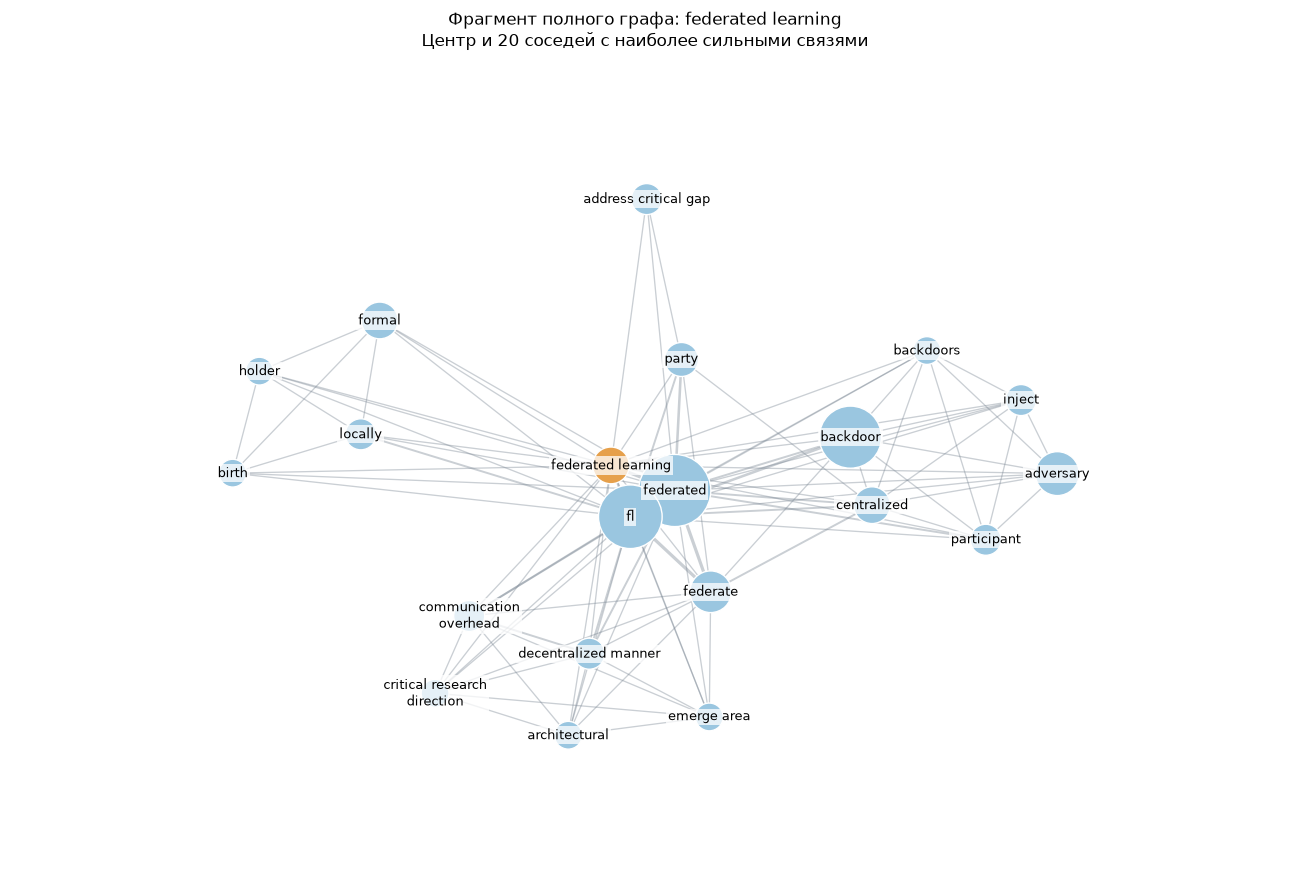

,keyword,weight,publication_count
0,federated,4,24
1,fl,3,18
2,address critical gap,1,2
3,adversary,1,7
4,architectural,1,1
5,backdoor,1,17
6,backdoors,1,1
7,birth,1,1
8,centralized,1,4
9,communication overhead,1,2


In [26]:
FOCUS_KEYWORD = "federated learning"
MAX_NEIGHBORS = 20
LAYOUT_SEED = 42


def select_keyword_neighborhood(graph, focus, max_neighbors=20):
    columns = ["keyword", "weight", "publication_count"]
    if focus not in graph:
        return nx.Graph(), pd.DataFrame(columns=columns)
    neighbors = sorted(graph.neighbors(focus), key=lambda term: (-graph[focus][term]["weight"], term))[:max_neighbors]
    table = pd.DataFrame([
        {"keyword": term, "weight": graph[focus][term]["weight"],
         "publication_count": graph.nodes[term]["publication_count"]}
        for term in neighbors
    ], columns=columns)
    # Явный порядок нужен и при новом ядре: subgraph не гарантирует порядок вершин.
    subgraph = graph.subgraph([focus] + neighbors)
    view = nx.Graph()
    view.add_nodes_from((term, subgraph.nodes[term]) for term in sorted(subgraph))
    view.add_edges_from(sorted(
        (min(source, target), max(source, target), attributes)
        for source, target, attributes in subgraph.edges(data=True)
    ))
    return view, table


keyword_graph_view, kg_neighbors = select_keyword_neighborhood(keyword_graph, FOCUS_KEYWORD, MAX_NEIGHBORS)
kg_positions = {}
if FOCUS_KEYWORD not in keyword_graph:
    print(f"Термина '{FOCUS_KEYWORD}' нет среди выбранных тегов. Рисунок пропущен; выберите существующий FOCUS_KEYWORD.")
else:
    if kg_neighbors.empty:
        print(f"'{FOCUS_KEYWORD}' — изолированная вершина, соседей нет.")
    kg_positions = nx.spring_layout(keyword_graph_view, seed=LAYOUT_SEED, weight="weight", k=0.9, iterations=100)
    kg_figure, kg_axis = plt.subplots(figsize=(13, 9))
    nx.draw_networkx_edges(
        keyword_graph_view, kg_positions, ax=kg_axis,
        width=[0.5 + 0.45 * data["weight"] for _, _, data in keyword_graph_view.edges(data=True)],
        edge_color="#7B8794", alpha=0.4,
    )
    nx.draw_networkx_nodes(
        keyword_graph_view, kg_positions, ax=kg_axis,
        node_size=[300 + 100 * keyword_graph_view.nodes[term]["publication_count"] for term in keyword_graph_view],
        node_color=["#E6A04B" if term == FOCUS_KEYWORD else "#9AC6E0" for term in keyword_graph_view],
        edgecolors="white", linewidths=1,
    )
    nx.draw_networkx_labels(
        keyword_graph_view, kg_positions, ax=kg_axis,
        labels={term: fill(term, width=20, break_long_words=False, break_on_hyphens=False) for term in keyword_graph_view},
        font_size=9, bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 1.5},
    )
    kg_axis.set_title(f"Фрагмент полного графа: {FOCUS_KEYWORD}\nЦентр и {len(kg_neighbors)} соседей с наиболее сильными связями")
    kg_axis.margins(0.2)
    kg_axis.set_axis_off()
    kg_figure.tight_layout()
    plt.show()
    display(kg_neighbors)

### Выводы по графу ключевых слов

В выполненном расчёте для **856 публикаций** построен граф из **4 491 вершины и
37 006 рёбер**. Публикаций без тегов и изолированных вершин нет. Граф состоит из
трёх компонент размером 4 471, 10 и 10 вершин: почти все термины соединены
путями, но граф в целом не связен. Компоненты связности — не результат
кластеризации.

Сумма весов равна **38 520**: у каждой статьи 10 разных тегов, поэтому каждая
даёт 45 пар, а 856 × 45 = 38 520. При этом **35 889 из 37 006 рёбер (около 97%)**
имеют вес 1: большинство пар выбрано вместе только в одной статье.
Повторяющихся связей значительно меньше, но все единичные связи сохранены.

Самая сильная пара — `federated` — `fl` (14 публикаций). Проверенные примеры
посвящены удалению данных и бэкдоров в федеративном обучении.
Пара `multimodal large` — `multimodal large language` (12) отражает исследования
мультимодальных языковых моделей, а `certify` — `certify unlearning` (11) —
методы удаления с теоретическими гарантиями. При этом последние две пары
содержат вложенные фразы: высокая совместная частота здесь частично связана
с правилами выделения n-грамм, а не только с близостью разных понятий.

`federated learning` выбран тегом **4 статей** и имеет **31 соседа** в полном
графе. Показанный фрагмент содержит центр и 20 соседей — всего **21 вершину
и 97 рёбер**, включая связи соседей друг с другом. Самые сильные связи центра:
с `federated` (4) и `fl` (3). Остальные показанные связи центра имеют вес 1;
при равенстве отбор ограничен алфавитным порядком. Это лишь часть окружения,
а не все статьи или термины о федеративном обучении. Соседи `backdoor`,
`adversary`, `communication overhead` показывают разные обсуждаемые аспекты.

Видны ограничения исходных тегов: общие слова вроде `formal`, фразы вроде
`address critical gap`, вложенные выражения и варианты `federate` / `federated`,
`backdoor` / `backdoors` влияют на структуру. Здесь они намеренно не исправляются
и не объединяются. Граф описывает **совместное назначение итоговых тегов**, а не
все совместные вхождения слов в текстах. Тег, назначенный всего одной статье,
может иметь много соседей за счёт других тегов этой статьи.

Совместное назначение не доказывает синонимию или причинную связь. Положение
вершин на рисунке не является кластеризацией; цвет выделяет только выбранный
центр. Вес ребра здесь означает **силу связи**. Для будущих центральностей,
основанных на кратчайших путях, способ перехода от силы связи к расстоянию
нужно будет выбрать отдельно.


## Кластеризация графа ключевых слов

Ищу сообщества **терминов**, а не публикаций: группы с выраженными внутренними
связями совместного назначения тегов. Компонента связности и сообщество —
разные понятия; одна большая компонента может содержать несколько сообществ.

Использую Louvain на полном `keyword_graph`, включая небольшие компоненты
и рёбра веса 1. Вес — число совместных публикаций, не расстояние и не TF-IDF.
Основной результат: `seed=42`, `resolution=1.0`. Число групп заранее не задаю.
Алгоритм эвристический и не гарантирует единственное лучшее разбиение.
Исходные таблицы, графы и их атрибуты не изменяю.
[Louvain в NetworkX](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.louvain.louvain_communities.html).

In [27]:
import math
from numbers import Real
from statistics import median
from sklearn.metrics import adjusted_rand_score
from matplotlib.patches import Patch

COMM_RESOLUTION = 1.0
COMM_SEED = 42
COMM_SEEDS = (0, 1, 2, 42, 100)


def detect_keyword_communities(graph, seed=42, resolution=1.0):
    if not isinstance(graph, nx.Graph) or graph.is_directed() or graph.is_multigraph():
        raise ValueError("Нужен неориентированный простой keyword_graph из предыдущего раздела.")
    if nx.number_of_selfloops(graph):
        raise ValueError("В графе обнаружены петли; выполните проверку предыдущего раздела.")
    for source, target, data in graph.edges(data=True):
        weight = data.get("weight")
        if isinstance(weight, bool) or not isinstance(weight, Real) or not math.isfinite(weight) or weight <= 0:
            raise ValueError(f"Ребро {source!r} — {target!r}: нужен положительный конечный числовой weight.")
    if not graph:
        return [], None
    if graph.number_of_edges() == 0:
        return [frozenset([term]) for term in sorted(graph)], None

    # Независимая рабочая копия с фиксированным порядком вершин и рёбер.
    ordered = nx.Graph()
    ordered.add_nodes_from(sorted(graph))
    ordered.add_weighted_edges_from(sorted(
        (min(source, target), max(source, target), data["weight"])
        for source, target, data in graph.edges(data=True)
    ))
    groups = nx.community.louvain_communities(
        ordered, weight="weight", resolution=resolution, seed=seed,
    )
    groups = sorted((frozenset(group) for group in groups), key=lambda group: (-len(group), tuple(sorted(group))))
    quality = nx.community.modularity(graph, groups, weight="weight", resolution=resolution)
    return groups, quality


if "keyword_graph" not in globals() or "keywords_df" not in globals():
    raise ValueError("Сначала выполните выделение ключевых слов и построение полного графа.")
comm_required = {"arxiv_id", "title", "abstract", "url", "keywords"}
if not isinstance(keywords_df, pd.DataFrame) or not comm_required.issubset(keywords_df.columns):
    raise ValueError("Нужна keywords_df с ID, названием, аннотацией, ссылкой и списками keywords из предыдущих разделов.")
keyword_communities, community_modularity = detect_keyword_communities(keyword_graph, COMM_SEED, COMM_RESOLUTION)
keyword_community_map = {
    term: community_id for community_id, group in enumerate(keyword_communities, 1) for term in sorted(group)
}
keyword_community_df = pd.DataFrame([
    {"keyword": term, "community_id": keyword_community_map[term],
     "publication_count": keyword_graph.nodes[term]["publication_count"]}
    for term in sorted(keyword_graph)
], columns=["keyword", "community_id", "publication_count"]).sort_values(
    ["community_id", "publication_count", "keyword"], ascending=[True, False, True]
).reset_index(drop=True)

print(f"NetworkX {nx.__version__}; Louvain, resolution={COMM_RESOLUTION}, seed={COMM_SEED}.")
if not keyword_communities:
    print("Терминов нет: кластеризация пропущена.")
elif community_modularity is None:
    print("Рёбер нет: сохранены одиночные сообщества. Модулярность и устойчивость не рассчитываются.")
else:
    print(f"Сообществ: {len(keyword_communities)}; модулярность Q = {community_modularity:.6f}.")

NetworkX 3.7; Louvain, resolution=1.0, seed=42.
Сообществ: 32; модулярность Q = 0.555798.


### Модулярность и устойчивость

Для неориентированного взвешенного графа:

$$Q=\sum_C\left[\frac{W_C}{W}-\gamma\left(\frac{S_C}{2W}\right)^2\right].$$

$W$ — общий вес рёбер, $W_C$ — внутренний вес сообщества (каждое ребро один раз),
$S_C$ — сумма взвешенных степеней его вершин: внутреннее ребро даёт два вклада,
выходящее наружу — один. В этом разделе $\gamma=1$.
Модулярность сравнивает фактические внутренние связи с ожидаемыми по модели,
учитывающей общую связанность вершин. Это не точность и не процент верно
найденных тем. Louvain оптимизирует ту же метрику; универсального порога
«хорошо/плохо» не задаю.
[Формула NetworkX](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.quality.modularity.html).

Меняю только seed. Основной результат 42 сохраняю даже при большем Q другого
запуска. ARI сравнивает состав групп относительно запуска 42, независимо
от перестановки номеров: 1 означает одинаковые разбиения, около 0 —
согласованность на уровне случайного совпадения; отрицательные значения возможны.
Здесь нет эталонной разметки: ARI характеризует устойчивость, а не точность.
[ARI в scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html).

In [28]:
community_runs = {COMM_SEED: keyword_communities}
comm_modularities = {COMM_SEED: community_modularity}
comm_stability_rows = []
if community_modularity is not None:
    comm_node_order = sorted(keyword_graph)
    comm_reference_labels = [keyword_community_map[term] for term in comm_node_order]
    for comm_seed in COMM_SEEDS:
        if comm_seed not in community_runs:
            community_runs[comm_seed], comm_modularities[comm_seed] = detect_keyword_communities(
                keyword_graph, comm_seed, COMM_RESOLUTION,
            )
        comm_groups = community_runs[comm_seed]
        comm_labels = {term: i for i, group in enumerate(comm_groups) for term in group}
        comm_sizes = [len(group) for group in comm_groups]
        comm_stability_rows.append({
            "seed": comm_seed, "modularity": comm_modularities[comm_seed],
            "community_count": len(comm_groups), "min_size": min(comm_sizes),
            "median_size": median(comm_sizes), "max_size": max(comm_sizes),
            "ari_vs_42": adjusted_rand_score(comm_reference_labels, [comm_labels[t] for t in comm_node_order]),
        })
community_stability = pd.DataFrame(comm_stability_rows, columns=[
    "seed", "modularity", "community_count", "min_size", "median_size", "max_size", "ari_vs_42",
])
if not community_stability.empty:
    display(community_stability.round({"modularity": 6, "ari_vs_42": 4}))

,seed,modularity,community_count,min_size,median_size,max_size,ari_vs_42
0,0,0.552793,34,10,121.0,354,0.2494
1,1,0.553989,35,10,130.0,253,0.2734
2,2,0.555424,30,10,151.5,316,0.3289
3,42,0.555798,32,10,121.5,348,1.0000
4,100,0.555615,30,10,146.5,302,0.2808


### Состав сообществ и подтверждающие статьи

ID присвоены по убыванию размера, при равенстве — по алфавитному списку терминов;
это не ранги качества. `publications_any` считает статьи хотя бы с одним тегом
группы, `publications_2plus` — минимум с двумя **различными** тегами.
Одна статья может поддерживать несколько групп, поэтому эти числа нельзя
складывать как размеры непересекающихся классов публикаций.

`top_keywords` — до 10 тегов по числу назначений статьям (`publication_count`),
при равенстве — по алфавиту. Это не DF кандидатов до отбора топ-10.
`internal_weight` — сумма весов внутренних рёбер, `is_connected` — связность
подграфа сообщества. Несвязные сообщества отмечаю, но автоматически не разделяю.

Для каждой группы `community_evidence` сохраняет до трёх статей с наибольшим
числом совпавших тегов (минимум два), при равенстве — по ID.
Аннотации сохраняются для содержательной проверки; ниже подробные примеры
показываются без длинных аннотаций.

In [29]:
def describe_keyword_communities(graph, communities, publications):
    summary_rows, evidence_rows = [], []
    records = publications[["arxiv_id", "title", "url", "abstract", "keywords"]].to_dict("records")
    for community_id, group in enumerate(communities, 1):
        matches = [(row, sorted(set(row["keywords"]) & group)) for row in records]
        subgraph = graph.subgraph(group)
        summary_rows.append({
            "community_id": community_id, "term_count": len(group),
            "internal_weight": subgraph.size(weight="weight"),
            "publications_any": sum(bool(terms) for _, terms in matches),
            "publications_2plus": sum(len(terms) >= 2 for _, terms in matches),
            "top_keywords": sorted(group, key=lambda term: (-graph.nodes[term]["publication_count"], term))[:10],
            "is_connected": nx.is_connected(subgraph),
        })
        selected = sorted(
            ((row, terms) for row, terms in matches if len(terms) >= 2),
            key=lambda item: (-len(item[1]), item[0]["arxiv_id"]),
        )[:3]
        for row, terms in selected:
            evidence_rows.append({
                "community_id": community_id, "arxiv_id": row["arxiv_id"], "title": row["title"],
                "url": row["url"], "abstract": row["abstract"],
                "matched_keywords": terms, "matched_count": len(terms),
            })
    return (
        pd.DataFrame(summary_rows, columns=["community_id", "term_count", "internal_weight",
                     "publications_any", "publications_2plus", "top_keywords", "is_connected"]),
        pd.DataFrame(evidence_rows, columns=["community_id", "arxiv_id", "title", "url", "abstract",
                     "matched_keywords", "matched_count"]),
    )


community_summary, community_evidence = describe_keyword_communities(keyword_graph, keyword_communities, keywords_df)
with pd.option_context("display.max_colwidth", None, "display.max_rows", None):
    display(community_summary.assign(top_keywords=community_summary["top_keywords"].map(", ".join)))
comm_unsupported = community_summary.loc[community_summary["publications_2plus"].eq(0), "community_id"].tolist()
comm_disconnected = community_summary.loc[community_summary["is_connected"].eq(False), "community_id"].tolist()
if comm_unsupported:
    print("Нет статей минимум с двумя тегами для сообществ:", comm_unsupported)
if comm_disconnected:
    print("Несвязные подграфы сообществ (оставлены без изменений):", comm_disconnected)

,community_id,term_count,internal_weight,publications_any,publications_2plus,top_keywords,is_connected
0,1,348,2117.0,223,98,"concept, multimodal, mllm, contrastive, module, multimodal large, multimodal large language, modality, visual, vision language",True
1,2,280,1596.0,166,74,"backdoor, defense, attack, detection, sisa, agent, poison, poisoning, shard, clean",True
2,3,257,1410.0,153,68,"vector, continual, layer, lora, remain datum, cl, mu method, stability, adaptation, calibration",True
3,4,257,1182.0,137,62,"llm unlearning, recommendation, robustness, query, recommender, relearn, failure, llm, benign, encoder",True
4,5,204,1256.0,134,58,"federated, client, fl, activation, federated unlearning, noise, server, neuron, pruning, claim",True
5,6,203,1027.0,122,49,"representation, token, residual, level, deletion, dnn, attribute, delete, record, representation level",True
6,7,200,1134.0,146,50,"memory, certify, certify unlearning, noisy, order, second order, convex, dp, error, phase",True
7,8,195,1119.0,147,53,"diffusion, prompt, diffusion model, distillation, feature, identity, box, projection, embed, self",True
8,9,187,919.0,129,46,"class, distribution, recognition, corpus, example, forget set, fact, selection, forget class, matching",True
9,10,184,913.0,94,40,"ml, zero, exact unlearning, shot, verifiable, datum removal, device, edge, exact, ml model",True


### Содержательная интерпретация всех сообществ

Ниже — интерпретация **текущего расчёта: 856 публикаций, 4 491 термин, Louvain с seed=42**. Просмотрены названия, аннотации и совпавшие теги всех подготовленных примеров: по три статьи для сообществ 1–30 и по одной для 31–32, всего 92 пары «сообщество — статья». Таблица выше содержит десять наиболее часто назначаемых терминов каждой группы; здесь поясняется их возможный смысл. Это аналитические описания, а не автоматически установленные названия научных направлений.

Примеры выбираются по числу совпавших тегов, а при равенстве — по ID. Поэтому они не обязаны представлять все подтемы большой группы; несколько из них отражают прежде всего словарь одной статьи. Совместное назначение не доказывает синонимию. Если изменить корпус или правила тегирования, эти текстовые интерпретации нужно пересмотреть.

| ID | Предполагаемая тема и ограничения интерпретации |
|---|---|
| 1 | **Мультимодальные модели и удаление концептов, но группа смешанная.** Частотное ядро — `multimodal`, `mllm`, `vision language`. Среди примеров есть UnlearnCanvas о диффузионных моделях, общий градиентный метод и обзор забывания в LLM: одной мультимодальной темой вся группа не исчерпывается. |
| 2 | **Безопасность: backdoor, отравление и защита моделей.** Backdoor Defense и PolicyCleanse подтверждают связку `backdoor`, `trigger`, `defense`, `agent`. Однако SISA для NLP и пара `quantum — quantum machine` показывают дополнительные методические ветви. |
| 3 | **Методы обновления моделей и последовательного забывания; смешанная группа.** Частые `continual`, `layer`, `lora` и пары с `continual learning` указывают на адаптацию. Подобранные статьи, напротив, подробно подтверждают байесовскую и MCMC-ветвь; весь кластер нельзя назвать только continual learning. |
| 4 | **LLM unlearning, оценка вмешательств и рекомендательные системы.** Примеры Rethinking Machine Unlearning, оценки LLM и Composable Interventions подтверждают первую часть, а сильная пара `recommendation — recommender` — вторую. Это не одна узкая тема. |
| 5 | **Федеративное и децентрализованное забывание.** `client`, `federated`, `fl`, `federated unlearning` связаны обзором FU, FedAU и HDUS. Ядро содержательно понятно, но есть общие слова и не объединённые варианты `federate` / `federated`. |
| 6 | **Удаление данных, записей и их представлений.** Descent-to-Delete, Class Clown и Forget Unlearning обсуждают гарантии удаления и сопровождение моделей; `delete`, `deletion`, `record`, `dnn` отражают эти задачи. Общие слова вроде `level` делают границы темы широкими. |
| 7 | **Сертифицированное забывание и шумовые методы оптимизации.** Minimax unlearning, Langevin unlearning и noisy SGD подтверждают `certify unlearning`, `dp`, `noisy`, `convex`. Это теоретико-алгоритмическое ядро; `certify` — лемматизированная форма, а вложенные фразы частично дублируют смысл. |
| 8 | **Управление генерацией: диффузия, retrieval и prompts.** CPR связывает диффузию и защиту авторских прав, Soft Prompting — запросы и забывание в LLM. Группа объединяет разные генеративные подходы, а не только diffusion models. |
| 9 | **Что именно удаляется: классы, документы, факты и наборы данных.** Dataset Condensation, Document Classification и RWKU поддерживают разные постановки выбора забываемых объектов. Общие `class`, `corpus`, `example` не означают, что методы этих работ одинаковы. |
| 10 | **Эффективное удаление данных, включая exact unlearning.** S3T подтверждает `exact unlearning`, но Deep Regression Unlearning и Random Relabeling добавляют другие методы. Вложенные `exact`, `exact machine`, `exact machine unlearning` усиливают лексическую связь. |
| 11 | **Риски приватности и обслуживание запросов в MLaaS.** Работы об уязвимостях сервисов, ERASER и reconstruction attacks связывают `owner`, `service`, `privacy risk`, `reconstruction`. Это пересечение инфраструктурных задач и атак, а не один тип атаки. |
| 12 | **Генерация и сохранение полезности моделей; смешанная группа.** Text-to-image alignment и MRI reconstruction объясняют `generative`, `alignment`, `image`, но пример Q-MUL относится к квантованным сетям. Для всей группы слишком узкая подпись «генеративные модели» была бы неточной. |
| 13 | **Медицинские применения и проверка безопасности.** Medical Imaging подтверждает `medical`, `patient`, `clinical`; две другие статьи посвящены качеству бенчмарков и восстановлению опасных возможностей LLM. Связь широкая, а `pretraine` показывает ограничение лемматизации. |
| 14 | **Графовое забывание, fairness и отдельная ветвь GAN.** Node-CUL подтверждает `graph`, `gnn`, `graph unlearning`; Fair Machine Unlearning — `fairness`, а GAN Unlearning — генераторы и дискриминаторы. Сообщество методически неоднородно. |
| 15 | **Обзоры, систематизация и проверка методов.** Все три примера — обзорные работы, включая Digital Forgetting; `survey`, `taxonomy` согласуются с их содержанием. `llms` и общие слова `type`, `field` не задают отдельную предметную тему. |
| 16 | **Запоминание, инверсия и утечки удаляемых данных.** CovarNav использует model inversion внутри метода, а Unlearning Inversion Attacks — как атаку. Общий словарь `inversion`, `leak`, `unlearned datum` объединяет разные роли одного механизма. |
| 17 | **Избирательное изменение параметров и сохранение знаний.** SSD и DeepClean используют информацию Фишера (`fisher`, `weight`, `post hoc`); Towards Natural Machine Unlearning добавляет изменение меток. Это не кластер одного алгоритма. |
| 18 | **Качество забывания, аудит и баланс целей.** SCRUB связывает метрики с назначением забывания, MUNBa разрешает конфликт забывания и сохранения, а Does Machine Unlearning Truly Remove Knowledge? проверяет результат. Группа объединяет оценку и оптимизацию. |
| 19 | **Забывание в моделях рассуждения и побочные изменения знаний.** Две работы подтверждают `reasoning`, `lrm`, `trace`, `answer` и утечки через промежуточные рассуждения. I-CARE относится к интерференции в генерации изображений, поэтому не всё сообщество — про LRM. |
| 20 | **Эффективное и устойчивое изменение параметров.** Scissorhands выделяет чувствительные параметры, Stable Forgetting стабилизирует градиентный подъём с LoRA, MRD-LiNet работает с компактной CNN. Сосуществование `transformer` и `transformers` показывает не полностью устранённые словоформы. |
| 21 | **Многозадачная оптимизация и геометрия представлений.** MulCanon соединяет забывание с кластеризацией графа знаний, NGDiff согласует цели, DUCK использует расстояния до центроидов. Узкая общая тема выделяется слабо. |
| 22 | **Влияние отдельных примеров, смещения и определения безопасности.** Статьи о сложности забывания примеров, FMD и Protecting the Undeleted объясняют `instance`, `difficulty`, `bias`, `counterfactual`, `definition`. Всю смешанную группу нельзя назвать только дебайсингом. |
| 23 | **Корректирующее и частичное забывание при ограниченных данных.** Примеры рассматривают испорченные данные, частичные послойные обновления и сгенерированные прокси. `corrective` / `corrective machine` / `corrective machine unlearning` — вложенные варианты одной фразы. |
| 24 | **Масштабируемое забывание и персональные данные.** CureNewton и Mini-Unlearning подтверждают численные методы, Learning to Refuse — сведения об отдельных людях. `personal datum` — нормализация выражения personal data, а не отдельное понятие. |
| 25 | **Неопределённость, обратимость забывания и управление данными.** Работы об эпистемической неопределённости и обратимости подтверждают оценочный мотив, но выплаты пользователям за сохранение данных — другая задача. `user`, `uncertainty`, `evaluation metric` не образуют одну узкую тему. |
| 26 | **Полнота забывания и ущерб сохраняемым данным.** LUCM, Group-robust и Similarity-Aware Machine Unlearning рассматривают полноту удаления, потери отдельных групп и похожие сохраняемые примеры. Вложенные выражения с `aware` добавляют лексические, не только тематические связи. |
| 27 | **Линейные методы, дообучение, маскирование и отдельная ветвь GAN.** Линейная фильтрация и анализ fine-tuning объясняют часть терминов, Machine unlearning via GAN представляет иной подход. Группа остаётся смешанной. |
| 28 | **Многоязычное забывание фактов и сущностей.** Работа о межъязыковом переносе и FAME с биографиями подтверждают `multilingual`, `entity`, `biography`. Adaptive RMU добавляет общий метод забывания фактов, не обязательно многоязычный. |
| 29 | **Проверка устойчивости и полноты забывания, включая генерацию.** Две статьи посвящены состязательной и комплексной оценке, No Encore — генерации музыки. `ad` / `ad hoc` — вложенные фрагменты выражения, а не самостоятельные темы. |
| 30 | **Речевые данные и общие градиентные методы.** Speech Unlearning и распознавание эмоций подтверждают речевое ядро; PGU — общий метод проекции градиентов. Вложенные выражения с `speech` частично повторяют одно содержание. |
| 31 | **Сравнительная оценка методов классификации — поддержка одной статьёй.** Десять тегов одной сравнительной работы образуют отдельную компоненту; это локальный словарь публикации, не подтверждённое несколькими работами направление. |
| 32 | **Маскирование нейронов — поддержка одной статьёй.** Десять тегов Learn to Forget включают `neuron masking`, вложенные выражения и общие слова. Плотная компонента отражает одну публикацию. |


In [30]:
comm_components = sorted(nx.connected_components(keyword_graph), key=lambda group: (-len(group), tuple(sorted(group))))
comm_largest_component = comm_components[0] if comm_components else set()
comm_detailed_ids = sorted(set(range(1, min(5, len(keyword_communities)) + 1)) | {
    i for i, group in enumerate(keyword_communities, 1) if group.isdisjoint(comm_largest_component)
})
comm_pair_rows = []
for comm_id in comm_detailed_ids:
    comm_group = keyword_communities[comm_id - 1]
    comm_pairs = sorted(
        ((min(u, v), max(u, v), data["weight"]) for u, v, data in keyword_graph.subgraph(comm_group).edges(data=True)),
        key=lambda pair: (-pair[2], pair[0], pair[1]),
    )[:5]
    comm_pair_rows.extend({"community_id": comm_id, "source": u, "target": v, "weight": w} for u, v, w in comm_pairs)
comm_top_pairs = pd.DataFrame(comm_pair_rows, columns=["community_id", "source", "target", "weight"])
for comm_id in comm_detailed_ids:
    print(f"Сообщество {comm_id}: {len(keyword_communities[comm_id - 1])} терминов")
    display(comm_top_pairs.loc[comm_top_pairs["community_id"].eq(comm_id), ["source", "target", "weight"]].reset_index(drop=True))
    comm_papers = community_evidence.loc[community_evidence["community_id"].eq(comm_id),
                                       ["arxiv_id", "title", "url", "matched_keywords"]]
    if comm_papers.empty:
        print("Нет подтверждающих статей минимум с двумя совпавшими тегами.")
    else:
        with pd.option_context("display.max_colwidth", None):
            display(comm_papers.assign(matched_keywords=comm_papers["matched_keywords"].map(", ".join)).reset_index(drop=True))

Сообщество 1: 348 терминов


,source,target,weight
0,multimodal large,multimodal large language,12
1,mllm,multimodal large,10
2,mllm,multimodal large language,10
3,mllm,multimodal,7
4,multimodal,multimodal large,7


,arxiv_id,title,url,matched_keywords
0,2402.11846,UnlearnCanvas: Stylized Image Dataset for Enhanced Machine Unlearning Evaluation in Diffusion Models,https://arxiv.org/abs/2402.11846,"challenge unlearn, challenge unlearn scenario, dispute, dm, dm unlearning, dms, enhanced machine, enhanced machine unlearning, image dataset, unlearncanvas"
1,2403.14339,$\nabla τ$: Gradient-based and Task-Agnostic machine Unlearning,https://arxiv.org/abs/2403.14339,"agnostic, agnostic machine, agnostic machine unlearning, datum example, face critical, gain significant, gain significant attention, gradient base, hyperparameter, task agnostic"
2,2403.15779,The Frontier of Data Erasure: Machine Unlearning for Large Language Models,https://arxiv.org/abs/2403.15779,"advance responsible, application like, data erasure, disseminate, ethical, introduce method, potentially memorize, preserve model integrity, selectively discard, textual datum"


Сообщество 2: 280 терминов


,source,target,weight
0,backdoor,trigger,6
1,backdoor,clean,5
2,quantum,quantum machine,5
3,reinforcement,reinforcement learning,4
4,reinforcement,reward,4


...

,source,target,weight
0,comparative,comparative analysis,1
1,comparative,comparative study,1
2,comparative,critical area,1
3,comparative,machine unlearning techniques,1
4,comparative,remove learn,1


,arxiv_id,title,url,matched_keywords
0,2412.19583,A Comparative Study of Machine Unlearning Techniques for Image and Text Classification Models,https://arxiv.org/abs/2412.19583,"comparative, comparative analysis, comparative study, critical area, machine unlearning techniques, remove learn, selectively remove learn, systematically analyze, text classification, unlearning techniques"


Сообщество 32: 10 терминов


,source,target,weight
0,conduct unlearning,contradict,1
1,conduct unlearning,eliminate memorization,1
2,conduct unlearning,network memorize,1
3,conduct unlearning,neural network memorize,1
4,conduct unlearning,neuron masking,1


,arxiv_id,title,url,matched_keywords
0,2003.10933,Learn to Forget: Machine Unlearning via Neuron Masking,https://arxiv.org/abs/2003.10933,"conduct unlearning, contradict, eliminate memorization, network memorize, neural network memorize, neuron masking, nowadays, potentially lead, rate, way"


### Подробный разбор выбранных сообществ

Выше показаны пары и статьи для пяти крупнейших групп и двух сообществ вне крупнейшей компоненты. Их ID: **1, 2, 3, 4, 5, 31, 32**. Все 32 подграфа сообществ в этом запуске связны; это структурный результат, не доказательство тематической однородности.

**Сообщество 1 — 348 терминов.** Самая сильная внутренняя пара — `multimodal large — multimodal large language` (12 публикаций), затем `mllm` с каждой из этих фраз (по 10). Это мультимодальное ядро, но первая пара фактически соединяет вложенные выражения. Подготовленные статьи показывают более широкий состав: [UnlearnCanvas](https://arxiv.org/abs/2402.11846) рассматривает забывание стилей и объектов в диффузионных моделях; [Gradient-based and Task-Agnostic machine Unlearning](https://arxiv.org/abs/2403.14339) — общий градиентный метод; [The Frontier of Data Erasure](https://arxiv.org/abs/2403.15779) — забывание в LLM. Примеры подтверждают несколько ветвей, а не единую мультимодальную тему. Группу поддерживают 98 статей минимум с двумя её тегами; дополнительные общие обороты вроде `gain significant attention` уменьшают однозначность интерпретации.

**Сообщество 2 — 280 терминов.** `backdoor — trigger` имеет вес 6, `backdoor — clean` — 5. [Backdoor Defense with Machine Unlearning](https://arxiv.org/abs/2201.09538) связывает восстановление триггеров с удалением backdoor, а [PolicyCleanse](https://arxiv.org/abs/2202.03609) — обнаружение и устранение троянского поведения RL-агентов. Это содержательное ядро безопасности. Однако [Privacy Adhering Machine Un-learning in NLP](https://arxiv.org/abs/2212.09573) посвящена SISA, а среди сильных пар есть `quantum — quantum machine` (5): вся группа шире backdoor-защиты. Поддержка минимум двумя тегами — 74 статьи. Вложенные `reinforcement` / `reinforcement learning` частично обозначают одно и то же.

**Сообщество 3 — 257 терминов.** Пары `continual — continual learning` и `continual — continual unlearning` имеют вес 5, `cl — continual learning` — 4. Они указывают на последовательное обучение и забывание. При этом три автоматически отобранных примера — [PAC-Bayesian framework](https://arxiv.org/abs/2106.00265), [Markov Chain Monte Carlo-Based Machine Unlearning](https://arxiv.org/abs/2202.13585) и [Knowledge Removal in Sampling-based Bayesian Inference](https://arxiv.org/abs/2203.12964) — подтверждают байесовскую ветвь и MCMC. Это смешанное сообщество методов, поддерживаемое 68 статьями минимум с двумя тегами. Многочисленные окна `markov chain`, `chain monte`, `chain monte carlo`, `monte carlo` описывают одно выражение и создают дополнительную локальную связность; три примера не представляют все 257 терминов.

**Сообщество 4 — 257 терминов.** Наиболее сильная пара `recommendation — recommender` имеет вес 8; `llm — llm unlearning` — 4. [Rethinking Machine Unlearning for Large Language Models](https://arxiv.org/abs/2402.08787) и [Towards Effective Evaluations and Comparisons for LLM Unlearning Methods](https://arxiv.org/abs/2406.09179) обсуждают постановку и оценку забывания в LLM; [Composable Interventions](https://arxiv.org/abs/2407.06483) — взаимодействие забывания, редактирования и сжатия. Они подтверждают LLM-часть группы, но не объясняют всю ветвь рекомендаций. Поэтому корректнее оставить смешанную интерпретацию, чем назвать кластер только «LLM». Поддержка минимум двумя тегами — 62 статьи; `intervention` и `interventions` показывают сохранившиеся варианты нормализации.

**Сообщество 5 — 204 термина.** Ядро наиболее явно связано с федеративным забыванием: `federated — fl` имеет вес 14, `client — federated` и `federated — federated unlearning` — по 11. [Обзор Federated Unlearning](https://arxiv.org/abs/2310.20448) рассматривает удаление вклада клиента; [Unlearning during Learning (FedAU)](https://arxiv.org/abs/2405.15474) — выполнение забывания в процессе обучения; [HDUS](https://arxiv.org/abs/2308.13269) — децентрализованные ансамбли моделей. Эти три свидетельства согласуются с ядром. Группу поддерживают 58 статей минимум с двумя тегами. При этом `federate`, `federated`, `fl`, `federate learning` не объединялись вручную, а `activation`, `noise`, `claim` в частотном списке не следует объявлять синонимами федеративного обучения.

**Сообщество 31 — 10 терминов, отдельная компонента.** Единственное подтверждение — [A Comparative Study of Machine Unlearning Techniques for Image and Text Classification Models](https://arxiv.org/abs/2412.19583). Аннотация сравнивает шесть методов для классификации изображений и текста. Все пять показанных пар, например `comparative — comparative analysis`, имеют вес 1. Десять тегов этой статьи образуют полный граф из 45 рёбер; других поддерживающих публикаций нет. `comparative analysis` и `comparative study`, а также `remove learn` и `selectively remove learn` показывают вложенность и особенности нормализации. Это группа с ограниченной поддержкой публикациями, а не самостоятельное устойчивое направление.

**Сообщество 32 — 10 терминов, отдельная компонента.** Единственное подтверждение — [Learn to Forget: Machine Unlearning via Neuron Masking](https://arxiv.org/abs/2003.10933). Работа описывает Forsaken, маскирование нейронов и оценку забывания через membership inference. Пары `conduct unlearning — neuron masking`, `conduct unlearning — eliminate memorization` и остальные показанные связи имеют вес 1. Здесь также 45 рёбер возникли из десяти тегов одной статьи. `network memorize` вложено в `neural network memorize`, а `nowadays`, `potentially lead`, `way` — общие обороты. Плотность не означает, что найдено отдельное направление, подтверждённое корпусом.

Для групп 31–32 это не противоречит `min_df=2` при извлечении терминов: кандидат мог встретиться в нескольких текстах, но быть выбран в итоговые топ-10 только одной статьи. Граф построен именно по выбранным тегам.


### Размеры сообществ и их отображение на графе

Первая диаграмма показывает число терминов, не число статей. На втором рисунке
использую тот же фрагмент и те же координаты, что в предыдущем разделе.
Теперь цвет обозначает сообщество из **полного** графа; выбранный центр
выделен контуром. Площадь вершины по-прежнему отражает число назначений тега,
толщина ребра — число совместных публикаций.
Раскладка не определяет кластеры; на фрагменте Louvain и модулярность не рассчитываю.

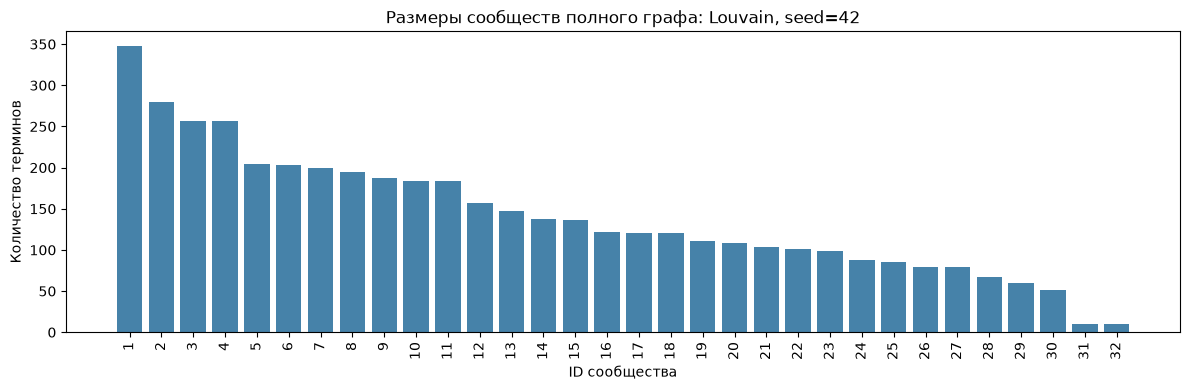

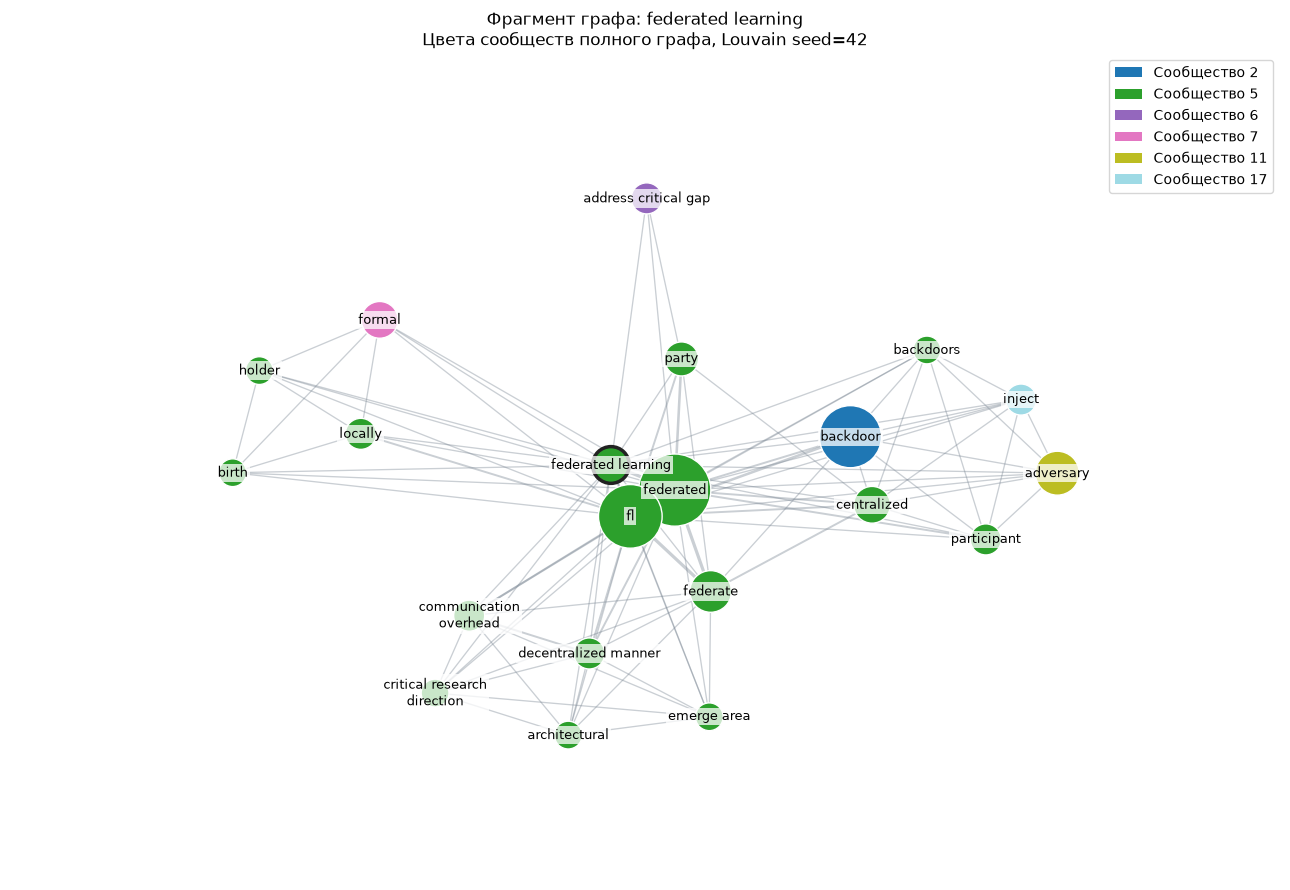

In [31]:
comm_color_map = {}
if not community_summary.empty:
    comm_size_figure, comm_size_axis = plt.subplots(figsize=(12, 4))
    comm_size_axis.bar(community_summary["community_id"].astype(str), community_summary["term_count"], color="#4682A9")
    comm_size_axis.set(xlabel="ID сообщества", ylabel="Количество терминов",
                       title="Размеры сообществ полного графа: Louvain, seed=42")
    comm_size_axis.tick_params(axis="x", labelrotation=90)
    comm_size_figure.tight_layout()
    plt.show()

if "keyword_graph_view" not in globals() or "kg_positions" not in globals():
    print("Для второго рисунка сначала выполните визуализацию графа в предыдущем разделе.")
elif FOCUS_KEYWORD not in keyword_graph or not keyword_graph_view:
    print(f"Центра '{FOCUS_KEYWORD}' нет: рисунок сообществ в окружении пропущен.")
else:
    comm_visible_ids = sorted({keyword_community_map[term] for term in keyword_graph_view})
    comm_palette = plt.get_cmap("tab20", max(1, len(comm_visible_ids)))
    comm_color_map = {community_id: comm_palette(i) for i, community_id in enumerate(comm_visible_ids)}
    comm_graph_figure, comm_graph_axis = plt.subplots(figsize=(13, 9))
    nx.draw_networkx_edges(
        keyword_graph_view, kg_positions, ax=comm_graph_axis,
        width=[0.5 + 0.45 * data["weight"] for _, _, data in keyword_graph_view.edges(data=True)],
        edge_color="#7B8794", alpha=0.4,
    )
    nx.draw_networkx_nodes(
        keyword_graph_view, kg_positions, ax=comm_graph_axis,
        node_size=[300 + 100 * keyword_graph_view.nodes[term]["publication_count"] for term in keyword_graph_view],
        node_color=[comm_color_map[keyword_community_map[term]] for term in keyword_graph_view],
        edgecolors=["#222222" if term == FOCUS_KEYWORD else "white" for term in keyword_graph_view],
        linewidths=[2.5 if term == FOCUS_KEYWORD else 1 for term in keyword_graph_view],
    )
    nx.draw_networkx_labels(
        keyword_graph_view, kg_positions, ax=comm_graph_axis,
        labels={term: fill(term, width=20, break_long_words=False, break_on_hyphens=False) for term in keyword_graph_view},
        font_size=9, bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 1.5},
    )
    comm_graph_axis.legend(handles=[Patch(facecolor=comm_color_map[i], label=f"Сообщество {i}") for i in comm_visible_ids], loc="upper right")
    comm_graph_axis.set_title(f"Фрагмент графа: {FOCUS_KEYWORD}\nЦвета сообществ полного графа, Louvain seed=42")
    comm_graph_axis.margins(0.2)
    comm_graph_axis.set_axis_off()
    comm_graph_figure.tight_layout()
    plt.show()

### Выводы по кластеризации

1. Полный граф из **4 491 термина** разбит на **32 сообщества**: от 10 до 348 терминов, медиана — 121,5. Все подграфы сообществ связны. В крупнейшей компоненте находятся 30 сообществ, две малые компоненты по десять вершин остались отдельными группами. Ничего из полного графа не исключалось.
2. Для основного запуска **Q = 0,555798** при `weight="weight"` и `resolution=1.0`. Это характеристика структуры разбиения относительно весовой нулевой модели, а не точность и не доказательство существования ровно 32 научных направлений. Louvain оптимизирует саму модулярность, поэтому проверка по статьям необходима.
3. В пяти запусках число сообществ меняется **от 30 до 35**, а Q — **от 0,552793 до 0,555798**. При этом ARI остальных четырёх запусков относительно seed=42 составляет только **0,2494–0,3289**. Значит, близкая модулярность сочетается с заметными изменениями состава групп: разбиение нельзя считать устойчивой единственной тематической картой. ARI=1 для seed=42 — сравнение результата с самим собой, не отдельное подтверждение качества. Основным сохранён заранее выбранный seed=42.
4. Выделяются понятные ядра: федеративное забывание, backdoor-защита, сертифицированные шумовые методы, инверсия и утечки, многоязычное и речевое забывание. Однако несколько крупных групп смешивают методы и приложения. В окрестности `federated learning` показаны метки **шести** сообществ полного графа (2, 5, 6, 7, 11, 17); центр принадлежит группе 5. Окрестность одного слова не обязана совпадать с одним сообществом, а положение узлов само по себе не является кластеризацией.
5. Эталонной разметки нет, поэтому численную «точность» не заявляем. Результат зависит от корпуса, лемматизации, списка стоп-слов и отбора не более десяти TF-IDF-тегов. Вложенные выражения и варианты словоформ усиливают или дробят связи. **Одна статья с десятью тегами создаёт 45 пар**: сообщества 31–32 показывают, как плотная изолированная группа может возникнуть из единственной публикации. Тематические подписи — осторожная интерпретация выбранных свидетельств, а не новые метки в исходном графе.

Для следующих этапов сохранены полный граф без изменений и отдельное соответствие терминов сообществам. Граф публикаций и центральности здесь не рассчитывались.


## Центральности ключевых слов

Сообщества описывают группы терминов, а центральности — положение отдельных терминов в графе. Рассчитываем три разных показателя на **полном графе**, сохраняя все компоненты и единичные связи:

| Показатель | Что он описывает |
|---|---|
| Degree centrality | Долю остальных вершин, с которыми термин связан непосредственно |
| Betweenness centrality | Долю кратчайших путей между другими вершинами, проходящих через термин |
| Closeness centrality | Обратную среднюю длину путей к достижимым вершинам с поправкой на их долю |

Это характеристики графа **итоговых выбранных тегов**, а не абсолютной научной значимости слов. Используем готовые `keyword_graph`, `keywords_df` и `keyword_community_map`; сбор данных, выделение тегов и Louvain здесь не запускаются. Eigenvector centrality в этот вариант не входит.

### Сила связи и расстояние

Исходный `weight` — число совместных публикаций: большой вес означает сильную связь. Для кратчайших путей принимаем модельное расстояние $\ell(u,v)=1/w(u,v)$, то есть повторные совместные назначения сокращают связь. Это допущение анализа, не измеренная семантическая дистанция.

Чтобы равные длины путей не различались из-за округления дробей, вычислим $L=\operatorname{НОК}\{w_e\}$ и сохраним целочисленное `distance = L // weight` только в независимой копии графа. Все пути удлиняются ровно в $L$ раз: их порядок и равенства сохраняются, betweenness не меняется. Для closeness после расчёта необходимо умножить результат на $L$, возвращая исходную шкалу $1/w$.

NetworkX предупреждает о численных проблемах взвешенного betweenness с дробными расстояниями: [документация](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.betweenness_centrality.html). Целыми здесь являются расстояния; итоговые центральности остаются числами с плавающей точкой.


In [32]:
import math
from copy import deepcopy
from numbers import Integral
from time import perf_counter
from textwrap import fill

KC_METRICS = ("degree_centrality", "betweenness_centrality", "closeness_centrality")
KC_RANK_COLUMNS = {
    "degree_centrality": "degree_rank",
    "betweenness_centrality": "betweenness_rank",
    "closeness_centrality": "closeness_rank",
}
KC_LABELS = {
    "degree_centrality": "Degree centrality",
    "betweenness_centrality": "Взвешенная betweenness",
    "closeness_centrality": "Closeness: 1/w, поправка WF",
}


def prepare_centrality_graph(graph):
    if not isinstance(graph, nx.Graph) or graph.is_directed() or graph.is_multigraph():
        raise ValueError("Нужен простой неориентированный keyword_graph из предыдущего раздела.")
    if nx.number_of_selfloops(graph):
        raise ValueError("В keyword_graph обнаружены петли; проверьте предыдущий раздел.")
    weights = set()
    for source, target, attributes in graph.edges(data=True):
        weight = attributes.get("weight")
        if isinstance(weight, bool) or not isinstance(weight, Integral) or weight <= 0:
            raise ValueError(f"Ребро {source!r} — {target!r}: weight должен быть положительным целым числом публикаций.")
        weights.add(int(weight))
    scale = math.lcm(*sorted(weights)) if weights else 1
    result = nx.Graph()
    result.graph.update(deepcopy(graph.graph))
    result.add_nodes_from((term, deepcopy(graph.nodes[term])) for term in sorted(graph))
    for source, target in sorted((min(u, v), max(u, v)) for u, v in graph.edges()):
        attributes = deepcopy(graph[source][target])
        attributes["distance"] = scale // int(attributes["weight"])
        result.add_edge(source, target, **attributes)
    return result, scale


if any(name not in globals() for name in ("keyword_graph", "keywords_df", "keyword_community_map")):
    raise ValueError("Сначала выполните выделение ключевых слов, построение графа и раздел кластеризации.")
kc_required = {"arxiv_id", "title", "abstract", "url", "keywords"}
if not isinstance(keywords_df, pd.DataFrame) or not kc_required.issubset(keywords_df.columns):
    raise ValueError("Нужна keywords_df с ID, названием, аннотацией, ссылкой и тегами из предыдущих разделов.")
centrality_graph, centrality_distance_scale = prepare_centrality_graph(keyword_graph)
if not isinstance(keyword_community_map, dict) or set(keyword_community_map) != set(centrality_graph):
    raise ValueError("Карта сообществ не соответствует вершинам графа; выполните предыдущий раздел кластеризации.")
print(f"Полный граф: {len(centrality_graph):,} вершин, {centrality_graph.number_of_edges():,} рёбер; L = {centrality_distance_scale}.")
if not centrality_graph:
    print("Терминов нет: результаты будут пустыми, рейтинги и рисунок пропущены.")
elif centrality_graph.number_of_edges() == 0:
    print("Рёбер нет: центральности равны нулю; содержательные рейтинги и рисунок не строятся.")


Полный граф: 4,491 вершин, 37,006 рёбер; L = 9240.


### Расчёт на полном графе

Для $N>1$ степень нормируется как $C_D(v)=k(v)/(N-1)$, где $k(v)$ — число разных соседей. Вес ребра здесь не используется: [degree centrality](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.degree_centrality.html).

Betweenness рассчитывается **по всем источникам** (`k=None`), без учёта концов пути (`endpoints=False`) и с нормировкой (`normalized=True`). При нескольких одинаково коротких маршрутах учитывается их доля. Приближённый расчёт автоматически не включается. Высокое значение означает посредничество на кратчайших путях, но само по себе не доказывает связь разных научных тем.

Для closeness применяем поправку Wasserman–Faust:

$$C_{WF}(v)=\frac{r_v}{N-1}\;\frac{r_v}{\sum_{u\ne v,\ u\text{ достижима}}d(v,u)},$$

где $r_v$ — число остальных достижимых вершин, а $d$ — кратчайшее расстояние в модели $1/w$. Благодаря первой дроби учитывается охват графа, а не только теснота небольшой компоненты. Используем `wf_improved=True`: [документация](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.closeness_centrality.html).

Взвешенная closeness может превышать 1: показатели не являются вероятностями. Для изолятов значения равны нулю; для единственной вершины явно принимаем такое же учебное соглашение для всех трёх метрик, поскольку формула степени делит на $N-1=0$.


In [33]:
def calculate_keyword_centralities(graph, distance_scale, community_map):
    if not isinstance(community_map, dict) or set(community_map) != set(graph):
        raise ValueError("Карта сообществ должна соответствовать всем вершинам графа.")
    if len(graph) <= 1:
        degree_values = betweenness_values = closeness_values = {term: 0.0 for term in graph}
    else:
        degree_values = nx.degree_centrality(graph)
        betweenness_values = nx.betweenness_centrality(
            graph, k=None, normalized=True, weight="distance", endpoints=False,
        )
        closeness_values = {
            term: value * distance_scale for term, value in nx.closeness_centrality(
                graph, distance="distance", wf_improved=True,
            ).items()
        }
    component_sizes = {term: len(component) for component in nx.connected_components(graph) for term in component}
    rows = []
    for term in sorted(graph):
        count = graph.nodes[term].get("publication_count")
        if isinstance(count, bool) or not isinstance(count, Integral) or count <= 0:
            raise ValueError(f"У термина {term!r} отсутствует корректный publication_count; проверьте построение графа.")
        values = (degree_values[term], betweenness_values[term], closeness_values[term])
        if any(not math.isfinite(value) or value < 0 for value in values):
            raise ValueError(f"Некорректные значения центральностей у термина {term!r}; расчёт не заменяется приближением.")
        rows.append({
            "keyword": term, "publication_count": count,
            "degree": graph.degree(term), "strength": graph.degree(term, weight="weight"),
            "degree_centrality": degree_values[term], "betweenness_centrality": betweenness_values[term],
            "closeness_centrality": closeness_values[term], "community_id": community_map[term],
            "component_size": component_sizes[term],
        })
    result = pd.DataFrame(rows, columns=[
        "keyword", "publication_count", "degree", "strength", "degree_centrality",
        "betweenness_centrality", "closeness_centrality", "community_id", "component_size",
    ])
    for metric in KC_METRICS:
        result[KC_RANK_COLUMNS[metric]] = result[metric].rank(method="min", ascending=False).astype("int64")
    return result


kc_started = perf_counter()
centrality_df = calculate_keyword_centralities(centrality_graph, centrality_distance_scale, keyword_community_map)
kc_elapsed = perf_counter() - kc_started
print(f"Три центральности рассчитаны для {len(centrality_df):,} терминов за {kc_elapsed:.1f} с; betweenness — по всем источникам.")
display(centrality_df.head(10).round({metric: 6 for metric in KC_METRICS}))


Три центральности рассчитаны для 4,491 терминов за 177.2 с; betweenness — по всем источникам.


,keyword,publication_count,degree,strength,degree_centrality,betweenness_centrality,closeness_centrality,community_id,component_size,degree_rank,betweenness_rank,closeness_rank
0,ablation study,1,9,9,0.002004,0.000000,0.300311,20,4471,1773,1772,3243
1,able,1,9,9,0.002004,0.000000,0.294889,6,4471,1773,1772,3472
2,absorb,1,9,9,0.002004,0.000000,0.303633,16,4471,1773,1772,3080
3,abstract,2,18,18,0.004009,0.000317,0.336666,3,4471,709,824,1120
4,abstract concept,1,9,9,0.002004,0.000000,0.299448,3,4471,1773,1772,3279
5,abundance,2,18,18,0.004009,0.000824,0.332269,25,4471,709,501,1332
6,academia,2,17,18,0.003786,0.000020,0.377072,15,4471,1441,1678,289
7,accelerate,1,9,9,0.002004,0.000000,0.325669,8,4471,1773,1772,1693
8,acceleration,1,9,9,0.002004,0.000000,0.336437,20,4471,1773,1772,1138
9,accelerator,2,18,18,0.004009,0.000452,0.326255,5,4471,709,691,1661


### Рейтинги и их пересечения

В `centrality_df` хранится одна строка на каждую вершину полного графа. `publication_count` — число статей, которым назначен итоговый тег, а не DF кандидата до отбора топ-10. `degree` — число разных соседей; `strength` — сумма весов связей. Если во всех статьях по десять тегов, `strength = 9 × publication_count`, поэтому это вспомогательный показатель, не четвёртая независимая центральность.

Места рассчитаны по убыванию (`rank(method="min")`): одинаковые значения имеют одинаковое место. Для отображения топ-10 равенства разрешаются по алфавиту; округление влияет только на вывод. Если на границе десятки несколько равных значений, алфавитный отбор не означает содержательного превосходства.

Рейтинги разных метрик сопоставляем по терминам и местам, а не по абсолютным величинам. Общий «балл важности» не вычисляется. Таблица пересечений показывает число общих терминов; диагональ — размер самого топа.


In [34]:
def rank_keyword_centralities(table, has_edges, top_n=10):
    overlap = pd.DataFrame(0, index=KC_METRICS, columns=KC_METRICS)
    if table.empty or not has_edges:
        return pd.DataFrame(columns=["metric", *table.columns]), overlap, []
    parts = [table.sort_values([metric, "keyword"], ascending=[False, True]).head(top_n).assign(metric=metric)
             for metric in KC_METRICS]
    top = pd.concat(parts, ignore_index=True)[["metric", *table.columns]]
    sets = {metric: set(top.loc[top["metric"].eq(metric), "keyword"]) for metric in KC_METRICS}
    for first in KC_METRICS:
        for second in KC_METRICS:
            overlap.loc[first, second] = len(sets[first] & sets[second])
    review_terms = []
    for part in parts:
        if not part.empty and part.iloc[0]["keyword"] not in review_terms:
            review_terms.append(part.iloc[0]["keyword"])
    indexed = table.set_index("keyword")
    rank_columns = list(KC_RANK_COLUMNS.values())
    union = set().union(*sets.values())
    candidates = sorted(union - set(review_terms), key=lambda term: (
        -(indexed.loc[term, rank_columns].max() - indexed.loc[term, rank_columns].min()), term,
    ))
    review_terms.extend(candidates[:max(0, 5 - len(review_terms))])
    return top, overlap, review_terms


centrality_top, centrality_overlap, kc_review_terms = rank_keyword_centralities(
    centrality_df, centrality_graph.number_of_edges() > 0,
)
if centrality_top.empty:
    print("Нет связей для содержательного ранжирования терминов.")
else:
    for kc_metric in KC_METRICS:
        print(KC_LABELS[kc_metric])
        with pd.option_context("display.max_colwidth", None):
            display(centrality_top.loc[centrality_top["metric"].eq(kc_metric), [
                "keyword", kc_metric, KC_RANK_COLUMNS[kc_metric], "publication_count", "degree", "community_id", "component_size",
            ]].reset_index(drop=True).round({kc_metric: 6}))
    display(centrality_overlap.rename(index=KC_LABELS, columns=KC_LABELS))


Degree centrality


,keyword,degree_centrality,degree_rank,publication_count,degree,community_id,component_size
0,mu,0.053007,1,28,238,18,4471
1,graph,0.039421,2,23,177,14,4471
2,survey,0.037416,3,21,168,15,4471
3,federated,0.035412,4,24,159,5,4471
4,diffusion,0.033853,5,20,152,8,4471
5,concept,0.033630,6,19,151,1,4471
6,memory,0.032739,7,17,147,7,4471
7,class,0.030067,8,16,135,9,4471
8,multimodal,0.030067,8,19,135,1,4471
9,contrastive,0.029621,10,16,133,1,4471


Взвешенная betweenness


,keyword,betweenness_centrality,betweenness_rank,publication_count,degree,community_id,component_size
0,mu,0.066802,1,28,238,18,4471
1,survey,0.062618,2,21,168,15,4471
2,concept,0.044116,3,19,151,1,4471
3,federated,0.042301,4,24,159,5,4471
4,multimodal,0.041473,5,19,135,1,4471
5,diffusion,0.040067,6,20,152,8,4471
6,mllm,0.038818,7,17,110,1,4471
7,ml,0.037030,8,16,133,10,4471
8,mia,0.036847,9,16,130,18,4471
9,backdoor,0.034501,10,17,123,2,4471


Closeness: 1/w, поправка WF


,keyword,closeness_centrality,closeness_rank,publication_count,degree,community_id,component_size
0,mu,0.475521,1,28,238,18,4471
1,concept,0.469636,2,19,151,1,4471
2,mllm,0.467109,3,17,110,1,4471
3,multimodal,0.466235,4,19,135,1,4471
4,federated,0.466225,5,24,159,5,4471
5,fl,0.464949,6,18,119,5,4471
6,survey,0.460206,7,21,168,15,4471
7,client,0.459794,8,18,121,5,4471
8,multimodal large,0.458516,9,12,79,1,4471
9,multimodal large language,0.458516,9,12,79,1,4471


,Degree centrality,Взвешенная betweenness,"Closeness: 1/w, поправка WF"
Degree centrality,10,6,5
Взвешенная betweenness,6,10,6
"Closeness: 1/w, поправка WF",5,6,10


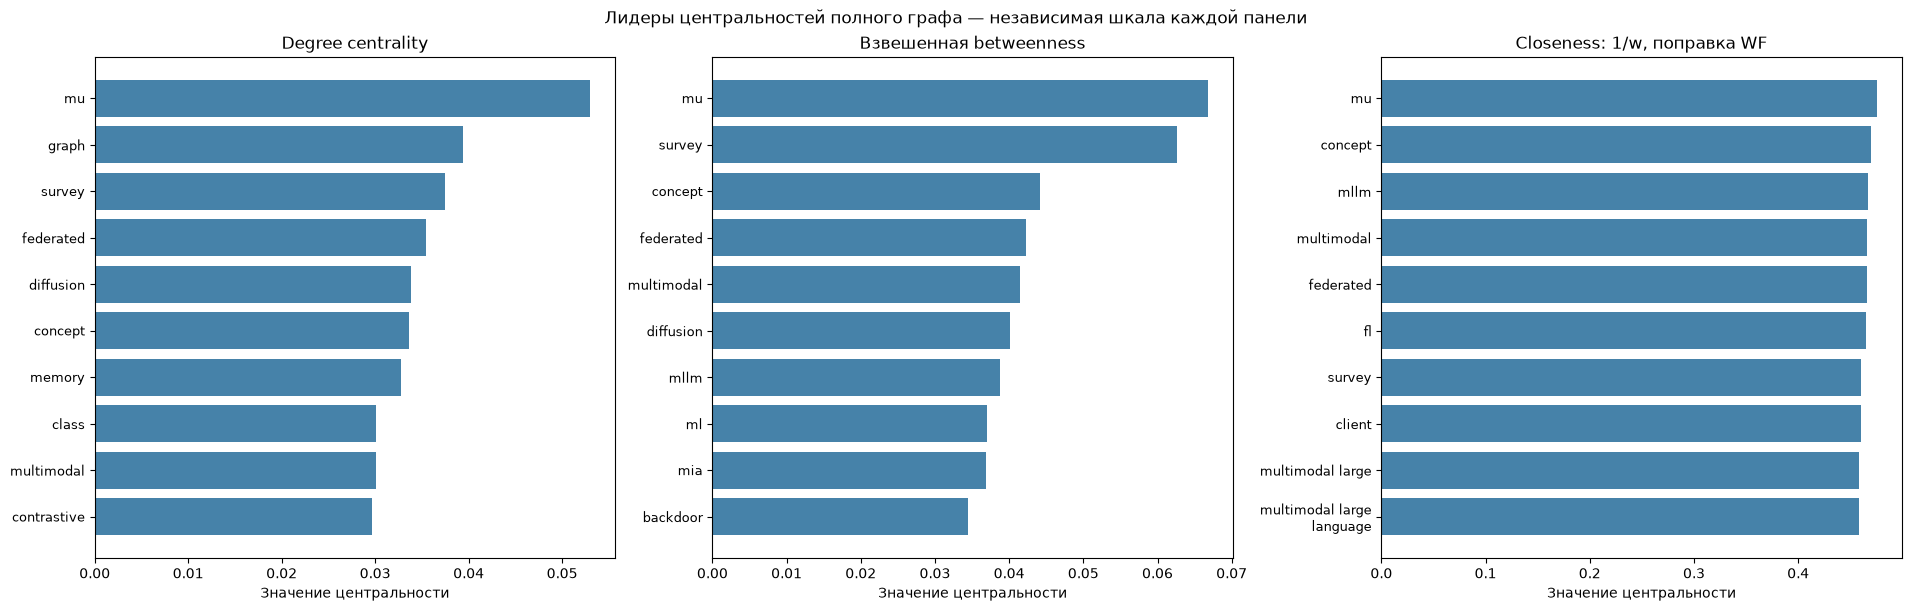

In [35]:
if not centrality_top.empty:
    kc_figure, kc_axes = plt.subplots(1, 3, figsize=(19, 6), layout="constrained")
    for kc_axis, kc_metric in zip(kc_axes, KC_METRICS):
        kc_panel = centrality_top.loc[centrality_top["metric"].eq(kc_metric)]
        kc_axis.barh(range(len(kc_panel)), kc_panel[kc_metric], color="#4682A9")
        kc_axis.set_yticks(range(len(kc_panel)), [fill(term, width=20, break_long_words=False) for term in kc_panel["keyword"]])
        kc_axis.invert_yaxis()
        kc_axis.set_title(KC_LABELS[kc_metric])
        kc_axis.set_xlabel("Значение центральности")
        kc_axis.tick_params(axis="y", labelsize=9)
        kc_axis.ticklabel_format(axis="x", style="plain", useOffset=False)
    kc_figure.suptitle("Лидеры центральностей полного графа — независимая шкала каждой панели")
    plt.show()
else:
    print("Рисунок пропущен: содержательных рейтингов нет.")


### Проверка содержательного смысла

Берём до пяти разных терминов: сначала лидеров трёх рейтингов, затем из объединения топ-10 — термины с наибольшей разницей между лучшим и худшим местом. При равенстве разницы используется алфавит. Это примеры разных структурных ролей, не новый общий рейтинг.

Для каждого термина показываем пять сильнейших соседей (по весу, затем по алфавиту) и до трёх статей. Все статьи содержат рассматриваемый тег; предпочитаются те, где больше показанных пяти соседей, при равенстве — меньший `arxiv_id`. Аннотации сохранены в `centrality_evidence` для содержательной проверки, но длинные тексты не печатаются целиком.

Высокая betweenness сама по себе не делает слово «мостом между научными направлениями». Проверяем окружение и публикации. Метки Louvain служат только контекстом: предыдущий раздел показал заметную изменчивость состава сообществ при разных seed.


In [36]:
def describe_centrality_terms(graph, publications, community_map, review_terms):
    neighbor_rows, evidence_rows = [], []
    papers = publications[["arxiv_id", "title", "url", "keywords", "abstract"]].to_dict("records")
    for term in review_terms:
        neighbors = sorted(graph.neighbors(term), key=lambda neighbor: (-graph[term][neighbor]["weight"], neighbor))[:5]
        neighbor_rows.extend({"keyword": term, "neighbor": neighbor,
                              "weight": graph[term][neighbor]["weight"], "community_id": community_map[neighbor]}
                             for neighbor in neighbors)
        shown = set(neighbors)
        eligible = [(paper, sorted(shown & set(paper["keywords"]))) for paper in papers if term in paper["keywords"]]
        selected = sorted(eligible, key=lambda item: (-len(item[1]), item[0]["arxiv_id"]))[:3]
        for paper, matches in selected:
            evidence_rows.append({
                "keyword": term, "arxiv_id": paper["arxiv_id"], "title": paper["title"], "url": paper["url"],
                "keywords": list(paper["keywords"]), "matched_neighbors": matches,
                "neighbor_matches": len(matches), "abstract": paper["abstract"],
            })
    return (
        pd.DataFrame(neighbor_rows, columns=["keyword", "neighbor", "weight", "community_id"]),
        pd.DataFrame(evidence_rows, columns=["keyword", "arxiv_id", "title", "url", "keywords",
                                           "matched_neighbors", "neighbor_matches", "abstract"]),
    )


kc_neighbors, centrality_evidence = describe_centrality_terms(
    centrality_graph, keywords_df, keyword_community_map, kc_review_terms,
)
print("Термины для подробного разбора:", kc_review_terms)
for kc_term in kc_review_terms:
    print(kc_term)
    with pd.option_context("display.max_colwidth", None, "display.max_columns", None):
        display(centrality_df.loc[centrality_df["keyword"].eq(kc_term)].round({metric: 6 for metric in KC_METRICS}))
        display(kc_neighbors.loc[kc_neighbors["keyword"].eq(kc_term), ["neighbor", "weight", "community_id"]].reset_index(drop=True))
        kc_papers = centrality_evidence.loc[centrality_evidence["keyword"].eq(kc_term), [
            "arxiv_id", "title", "url", "keywords", "matched_neighbors", "neighbor_matches",
        ]]
        if kc_papers.empty:
            print("В исходной таблице не найдено подтверждающих публикаций; интерпретация ограничена.")
        else:
            display(kc_papers.assign(keywords=kc_papers["keywords"].map(", ".join),
                                     matched_neighbors=kc_papers["matched_neighbors"].map(", ".join)).reset_index(drop=True))


Термины для подробного разбора: ['mu', 'multimodal large', 'multimodal large language', 'memory', 'graph']
mu


,keyword,publication_count,degree,strength,degree_centrality,betweenness_centrality,closeness_centrality,community_id,component_size,degree_rank,betweenness_rank,closeness_rank
2837,mu,28,238,252,0.053007,0.066802,0.475521,18,4471,1,1,1


,neighbor,weight,community_id
0,mu method,4,3
1,ai,2,12
2,auditor,2,6
3,baseline like,2,3
4,label,2,17


,arxiv_id,title,url,keywords,matched_neighbors,neighbor_matches
0,2410.01276,Deep Unlearn: Benchmarking Machine Unlearning for Image Classification,https://arxiv.org/abs/2410.01276,"dnn, proper, initialization, mu method, mu, hyperparameter, base membership, base membership inference, baseline like, evaluation involve","baseline like, mu method",2
1,2306.05670,One-Shot Machine Unlearning with Mnemonic Code,https://arxiv.org/abs/2306.05670,"fim, calculate, incur significant, sophisticated, mu method, exist mu method, exist mu, incur, mu, computational cost",mu method,1
2,2310.12508,SalUn: Empowering Machine Unlearning via Gradient-based Weight Saliency in Both Image Classification and Generation,https://arxiv.org/abs/2310.12508,"salun, saliency, unlearning accuracy, weight saliency, mu, weight, stability, image classification, baseline like, contain model",baseline like,1


multimodal large


...

,arxiv_id,title,url,keywords,matched_neighbors,neighbor_matches
0,2605.17590,Form and Function: Machine Unlearning as a Problem of Misaligned States,https://arxiv.org/abs/2605.17590,"counterfactual, bfgs, optimizer state, error, memory, stream, optimizer, online, correction, state","bfgs, online, optimizer, optimizer state",4
1,2508.10193,"Mo' Memory, Mo' Problems: Stream-Native Machine Unlearning",https://arxiv.org/abs/2508.10193,"regret, stream, online, memory, ml, bfgs, expensive retraining, logarithmic, ml pipeline, online setting","bfgs, online",2
2,2604.23046,Shape of Memory: a Geometric Analysis of Machine Unlearning in Second-Order Optimizers,https://arxiv.org/abs/2604.23046,"second order optimizer, order optimizer, second order, optimizer, order, second, geometric, memory, detectable, optimizer state","optimizer, optimizer state",2


graph


,keyword,publication_count,degree,strength,degree_centrality,betweenness_centrality,closeness_centrality,community_id,component_size,degree_rank,betweenness_rank,closeness_rank
1949,graph,23,177,207,0.039421,0.027842,0.428857,14,4471,2,14,37


,neighbor,weight,community_id
0,graph unlearning,8,14
1,gnn,7,14
2,knowledge graph,4,21
3,graph neural,3,14
4,kg,3,21


,arxiv_id,title,url,keywords,matched_neighbors,neighbor_matches
0,2503.02959,Node-level Contrastive Unlearning on Graph Neural Networks,https://arxiv.org/abs/2503.02959,"node, graph, embedding, gnn, structured datum, target node, graph unlearning, euclidean, graph neural, embed space","gnn, graph neural, graph unlearning",3
1,2206.09140,Certified Graph Unlearning,https://arxiv.org/abs/2206.09140,"graph, gnn, graph information, node, graph unlearning, test accuracy, complete retraining, complete, complexity, approach suffer","gnn, graph unlearning",2
2,2304.02835,GIF: A General Graph Unlearning Strategy via Influence Function,https://arxiv.org/abs/2304.02835,"graph unlearning, graph, influence function, gnn, gnn model, parameter change, graph unlearn, function, neighbor, dependency","gnn, graph unlearning",2


### Интерпретация выбранных терминов

Ниже — разбор фактически полученных результатов для 856 публикаций. Просмотрены аннотации всех выбранных свидетельств: 15 строк таблицы соответствуют 12 различным статьям, поскольку две вложенные фразы приводят к одним и тем же примерам. Все пять рассматриваемых терминов находятся в крупнейшей компоненте из 4 471 вершины. Места далее перечислены в порядке **degree / betweenness / closeness**.

**1. `mu`: общий термин с широким окружением.** Тег назначен 28 статьям и имеет 238 разных соседей. Он занимает первое место по всем трём метрикам: 0,053007 / 0,066802 / 0,475521. В выбранных аннотациях MU явно расшифровывается как Machine Unlearning: это сокращение общей темы, а не отдельное узкое направление. Полная форма и сокращение при нормализации не объединялись.

Сильнейшая связь — с `mu method` (4 статьи); связи с `ai`, `auditor`, `baseline like` и `label` имеют вес 2. Эти соседи относятся к разным сообществам основного Louvain, но метки сами по себе не доказывают межтематическое посредничество. Свидетельства действительно относятся к разным методическим контекстам: [Deep Unlearn](https://arxiv.org/abs/2410.01276) сравнивает методы и способы оценки; [One-Shot Machine Unlearning with Mnemonic Code](https://arxiv.org/abs/2306.05670) использует информацию Фишера и код для снижения вычислительных затрат; [SalUn](https://arxiv.org/abs/2310.12508) рассматривает значимость весов для классификации и генерации изображений. Поэтому наблюдаемое лидерство согласуется с ролью общего обозначения, связывающего разнообразные описания методов. Называть его самостоятельным научным «мостом» только по betweenness нельзя. `baseline like` показывает, что в граф попали и неудачные фрагменты речи.

**2. `multimodal large`: близость к хорошо связанному окружению.** У фразы 12 назначений и 79 соседей, места — 59 / 175 / 9. Значения: 0,017595 / 0,003197 / 0,458516. Сильные связи с `multimodal large language` (12), `mllm` (10) и `multimodal` (7) дают короткие расстояния в модели 1/w. Это помогает понять, почему фраза находится высоко по closeness, хотя имеет меньше прямых соседей и заметно уступает по betweenness.

Все три примера содержательно относятся к разучиванию мультимодальных больших языковых моделей: [MLLMU-Bench](https://arxiv.org/abs/2410.22108) проверяет удаление персональных сведений; [MLLMU-Med](https://arxiv.org/abs/2508.04192) — приватной информации и ошибочных знаний в биомедицинском контексте; [MMUnlearner](https://arxiv.org/abs/2502.11051) предлагает удалять визуальные шаблоны с сохранением соответствующих текстовых знаний. Это поддерживает тематическую интерпретацию окружения, но сама биграмма `multimodal large` является неполным выражением.

**3. `multimodal large language`: структурный двойник вложенной фразы.** У этого тега те же 12 публикаций, те же 79 соседей по количеству и в точности те же значения и места всех трёх метрик: 59 / 175 / 9. Дополнительная проверка исходных списков показала: обе фразы выбраны в одних и тех же 12 статьях; их внешние соседи и соответствующие веса совпадают, а друг с другом они связаны ребром веса 12. Поэтому их роли симметричны, а выбранные статьи совпадают — это не независимые подтверждения двух разных тем.

Обе фразы являются вложенными фрагментами четырёхсловного выражения `multimodal large language model`, которое целиком не входит в кандидаты длиной 1–3 слова. Их сильная взаимная связь частично создана правилами извлечения тегов. Высокая closeness при сравнительно низкой betweenness согласуется с наличием близкого, во многом взаимозаменяемого окружения. На этом этапе фразы не объединяем и не удаляем: фиксируем ограничение первой версии.

**4. `memory`: много соседей, но не лидерство по глобальным путям.** Тег встречается среди выбранных в 17 статьях и связан со 147 терминами; места — 7 / 17 / 52, значения — 0,032739 / 0,022112 / 0,418842. Пять показанных связей имеют вес 2: `bfgs`, `online`, `optimizer`, `optimizer state`, `store`. Все относятся к сообществу 7 основного запуска.

В выбранных примерах речь не просто о запоминании обучающих данных, а о памяти и состоянии оптимизатора: [Form and Function](https://arxiv.org/abs/2605.17590) сопоставляет фактическое и контрфактическое состояния online L-BFGS; [Mo’ Memory, Mo’ Problems](https://arxiv.org/abs/2508.10193) рассматривает потоковое разучивание и расходы памяти; [Shape of Memory](https://arxiv.org/abs/2604.23046) — остаточную информацию в состоянии оптимизаторов второго порядка. Это объясняет выбранное окружение, но не исчерпывает все значения общего слова `memory` в 17 статьях. Большое число непосредственных связей здесь не превращается в столь же высокую близость ко всей достижимой части графа.

**5. `graph`: широкий графовый контекст.** Тег назначен 23 статьям, имеет 177 соседей и места 2 / 14 / 37; значения — 0,039421 / 0,027842 / 0,428857. Сильнейшие связи — `graph unlearning` (8) и `gnn` (7); далее `knowledge graph` (4), `graph neural` (3), `kg` (3). Окружение включает сообщества 14 и 21, однако это контекст выбранного разбиения, не доказательство устойчивой границы тем.

Три подтверждающие статьи раскрывают разные подходы к разучиванию GNN: [Node-level Contrastive Unlearning](https://arxiv.org/abs/2503.02959) работает с пространством вложений узлов, [Certified Graph Unlearning](https://arxiv.org/abs/2206.09140) — с гарантиями удаления информации об узлах, рёбрах и признаках, [GIF](https://arxiv.org/abs/2304.02835) — с функцией влияния и зависимостями соседних узлов. По этим примерам `graph` — содержательный общий тег графовых методов. Его высокая степень отражает разнообразное непосредственное окружение, но сама по себе не гарантирует лидирующего посредничества или минимальных средних расстояний.


### Выводы по центральностям

- Рассчитаны три центральности для всех **4 491 термина** графа с **37 006 рёбрами**. Сохранены три компоненты размеров 4 471, 10 и 10; нормировки учитывают полный граф. НОК весов равен **9 240** и вычислен из данных. Betweenness рассчитана полностью, без выборки источников; фактическое время показано в ячейке расчёта.
- **`mu` лидирует во всех трёх рейтингах**, но это результат для общего сокращения Machine Unlearning в выбранном представлении корпуса, а не доказательство его научной важности. Топ-10 degree и betweenness имеют 6 общих терминов, degree и closeness — 5, betweenness и closeness — 6. Все три списка объединяют `mu`, `survey`, `federated`, `concept` и `multimodal`. Таким образом, рейтинги частично совпадают, но описывают разные структурные роли.
- Различия особенно заметны у `graph` и `memory`: высокие места по числу соседей не означают столь же высоких мест по путевым метрикам. Две вложенные мультимодальные фразы, напротив, входят в топ closeness при меньшем числе соседей; их одинаковые показатели объясняются совпадающими назначениями и симметричным окружением.
- Интерпретация ограничена корпусом arXiv, поисковой тематикой, TF-IDF, порогами частот и отбором **топ-10 тегов**. В текущей выборке у каждой статьи ровно десять тегов: она добавляет каждому своему тегу девять совместных назначений, то есть девять потенциальных соседей (часть из них уже может существовать в графе). Поэтому `strength = 9 × publication_count` и не даёт здесь независимого рейтинга.
- Общие слова, неполные словосочетания, вложенные n-граммы и не объединённые сокращения заметно влияют на результат. Расстояние 1/w — модельное решение; рейтинги зависят от него. Метки Louvain использованы лишь как вспомогательное описание окружения с учётом уже обнаруженной неустойчивости. Ни центральности, ни совпадение рейтингов не являются точностью относительно эталона или оценкой всей научной области.

Числа и содержательные выводы выше относятся к текущему сохранённому расчёту. Если состав корпуса или правила тегирования изменятся, Markdown-интерпретацию необходимо пересмотреть после повторного выполнения.
